#  Objective 1: Scanner Identification

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install torch torchvision torchaudio
!pip install opencv-python pillow scikit-learn tqdm matplotlib


## Set the Root Path

In [3]:
# Now set the full path
import os
ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
print(f"Root path set to: {ROOT}")


# Base folder where all datasets are stored
base_folder = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/"

# Dataset folder names
datasets = [
    "OfficialData",
    "FlatfieldData",
    "TamperedData",
    "WikipediaData",
    "OriginalData"
]

# Create a dictionary mapping dataset names to absolute paths
dataset_paths = {
    name.replace("Data", "").lower(): os.path.abspath(
        os.path.join(base_folder, name)
    )
    for name in datasets
}

# Verify dataset availability
print("Dataset paths and availability:\n")
for key, path in dataset_paths.items():
    print(f"{key:10s} -> {path} | Exists: {os.path.exists(path)}")


Root path set to: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData
Dataset paths and availability:

official   -> /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData | Exists: True
flatfield  -> /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/FlatfieldData | Exists: True
tampered   -> /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/TamperedData | Exists: True
wikipedia  -> /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/WikipediaData | Exists: True
original   -> /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OriginalData | Exists: True


# Milestone 1 — Dataset collection and preprocessing

Mounts Google Drive at /content/drive to access the ForensicsScannerData dataset.

Recursively traverses the directory:
    /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData

and prints each folder name with the count of files directly inside it.

Tracks and accumulates file counts for each top-level category
(e.g., OfficialData, WikipediaData, Features, TamperedData, etc.).

Prints a hierarchical view with indentation showing subfolders under each main folder.

After traversal, prints a summary table of total files per main folder.

Computes and displays a grand total of all files counted across the
ForensicsScannerData directory tree.


EDA on folders

In [4]:
import os
from google.colab import drive

# Mount Google Drive (safe mount)
drive.mount('/content/drive', force_remount=False)

# Root dataset directory (FINAL STRUCTURE)
DATASET_ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"

# Dictionary to store cumulative file counts
main_counts = {}

def print_tree_counts(path, indent="", top_level=None):
    """
    Recursively prints folder structure and counts files.
    Also accumulates file counts for top-level folders.
    """
    global main_counts

    try:
        items = sorted(os.listdir(path))
    except PermissionError:
        return

    file_count = sum(
        1 for i in items if os.path.isfile(os.path.join(path, i))
    )

    print(f"{indent}📁 {os.path.basename(path)}/ ({file_count} files)")

    # Track counts for top-level dataset folders
    if top_level is not None:
        main_counts[top_level] = main_counts.get(top_level, 0) + file_count

    for item in items:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # First level folders (OfficialData, FlatfieldData, etc.)
            if indent == "":
                print_tree_counts(item_path, indent + "    ", top_level=item)
            else:
                print_tree_counts(item_path, indent + "    ", top_level=top_level)

# Run traversal
print_tree_counts(DATASET_ROOT)

# Summary statistics
print("\n📊 Total files per dataset folder:")
for folder, count in main_counts.items():
    print(f"  {folder}: {count} files")

print(f"\n✅ Grand Total Files: {sum(main_counts.values())}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 ForensicsScannerData/ (0 files)
    📁 Features/ (8 files)
        📁 metrics/ (3 files)
        📁 models/ (5 files)
    📁 FlatfieldData/ (0 files)
        📁 Canon120-1/ (2 files)
        📁 Canon120-2/ (2 files)
        📁 Canon220/ (2 files)
        📁 Canon9000-1/ (2 files)
        📁 Canon9000-2/ (2 files)
        📁 EpsonV370-1/ (2 files)
        📁 EpsonV370-2/ (2 files)
        📁 EpsonV39-1/ (3 files)
        📁 EpsonV39-2/ (2 files)
        📁 EpsonV550/ (2 files)
        📁 HP/ (2 files)
    📁 OfficialData/ (0 files)
        📁 Canon120-1/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon120-2/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon220/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon9000-1/ (0 files)
            📁 150/ (100 files)
    

Mounts Google Drive and prepares access to the dataset within:

    /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData

Auto-discovers the Flatfield directory anywhere under this root using a case-insensitive search.

Sets output path to save preprocessed residuals as:

    flatfield_residuals.pkl

inside the Flatfield parent folder.

Imports denoisers (Wiener and wavelet), defaulting to Wiener; installs scikit-image on demand for wavelet.

Defines a preprocessing routine:
    read image → convert to grayscale → resize to 256×256 → normalize → denoise →
    compute residual = image − denoised.

Iterates all scanners and valid image files in Flatfield, skipping hidden/metadata files
(e.g., ._ , Thumbs.db).

Accumulates residuals per scanner.

Saves a dictionary:

    { scanner_name : [residual arrays] }

to flatfield_residuals.pkl for downstream fingerprint extraction.

Prints a summary showing:
    • number of scanners processed
    • number of images processed
    • example scanner keys


In [5]:
import os, pickle, cv2, numpy as np
from tqdm import tqdm
from scipy.signal import wiener

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FLATFIELD_DIR = os.path.join(BASE_DIR, "FlatfieldData")
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
os.makedirs(FEATURES_DIR, exist_ok=True)

OUT_PKL = os.path.join(FEATURES_DIR, "flatfield_residuals.pkl")

IMG_SIZE = (256, 256)

def preprocess_image_residual(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None

    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #  RESIZE
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)

    #  NORMALIZE
    img = img.astype(np.float32) / 255.0

    #  DENOISE
    den = wiener(img, (5,5))

    #  PURE RESIDUAL
    res = img - den

    return res.astype(np.float32)

flatfield_residuals = {}

for scanner in tqdm(sorted(os.listdir(FLATFIELD_DIR)), desc="Scanners"):
    scanner_dir = os.path.join(FLATFIELD_DIR, scanner)
    if not os.path.isdir(scanner_dir):
        continue

    residuals = []
    for fname in sorted(os.listdir(scanner_dir)):
        if fname.startswith("._"):
            continue
        if fname.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):
            fpath = os.path.join(scanner_dir, fname)
            try:
                res = preprocess_image_residual(fpath)
                if res is not None:
                    residuals.append(res)
            except Exception as e:
                print(f"⚠️ Failed on {fpath}: {e}")

    if residuals:
        flatfield_residuals[scanner] = residuals

with open(OUT_PKL, "wb") as f:
    pickle.dump(flatfield_residuals, f)

print(f"✅ Flatfield residuals saved: {OUT_PKL}")
print(f"Scanners: {len(flatfield_residuals)}")


Scanners: 100%|██████████| 11/11 [01:23<00:00,  7.62s/it]


✅ Flatfield residuals saved: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/flatfield_residuals.pkl
Scanners: 11


Defines a fast residual-preprocessing pipeline for Official and Wikipedia datasets using grayscale, 256×256 resize, normalization, and Haar wavelet denoising.

Implements denoise_wavelet by zeroing DWT detail coefficients (cH, cV, cD) and reconstructing, then computes residual = image − denoised.

Processes data hierarchically by scanner and DPI (150, 300), preserving structure in an output dictionary.

Uses ThreadPoolExecutor to parallelize per-file preprocessing for speed on Colab.

Filters valid image extensions (.tif, .tiff, .jpg, .jpeg, .png) and skips non-directories safely.

Saves all residuals into official_wiki_residuals.pkl with separate entries for Official and Wikipedia and for each scanner/DPI.



In [6]:
import os, cv2, numpy as np, pickle, pywt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---------------- PATHS ----------------
BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
OFFICIAL_DIR = os.path.join(BASE_DIR, "OfficialData")
WIKI_DIR = os.path.join(BASE_DIR, "WikipediaData")
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
os.makedirs(FEATURES_DIR, exist_ok=True)

OUT_PKL = os.path.join(FEATURES_DIR, "official_wiki_residuals.pkl")

# ---------------- PARAMS ----------------
IMG_SIZE = (256,256)

# ---------------- WAVELET DENOISE (BASELINE) ----------------
def denoise_wavelet(img):
    cA, (cH, cV, cD) = pywt.dwt2(img, 'haar')
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    return pywt.idwt2((cA,(cH,cV,cD)), 'haar')

def compute_residual(img):
    den = denoise_wavelet(img)
    return img - den

# ---------------- IMAGE PIPELINE ----------------
def process_image(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return compute_residual(img).astype(np.float32)

# ---------------- DATASET LOOP ----------------
def process_dataset(root, name, store):
    for scanner in tqdm(sorted(os.listdir(root)), desc=name):
        sp = os.path.join(root, scanner)
        if not os.path.isdir(sp):
            continue

        store[name][scanner] = {}
        for dpi in sorted(os.listdir(sp)):
            dp = os.path.join(sp, dpi)
            if not os.path.isdir(dp):
                continue

            files = [os.path.join(dp, f) for f in os.listdir(dp)
                     if not f.startswith("._")
                     and f.lower().endswith((".tif",".tiff",".jpg",".jpeg",".png"))]

            residuals = []
            with ThreadPoolExecutor(max_workers=8) as ex:
                futures = [ex.submit(process_image, f) for f in files]
                for fut in as_completed(futures):
                    r = fut.result()
                    if r is not None:
                        residuals.append(r)

            store[name][scanner][dpi] = residuals

# ---------------- RUN ----------------
residuals_dict = {"Official": {}, "Wikipedia": {}}
process_dataset(OFFICIAL_DIR, "Official", residuals_dict)
process_dataset(WIKI_DIR, "Wikipedia", residuals_dict)

with open(OUT_PKL, "wb") as f:
    pickle.dump(residuals_dict, f)

print(f"✅ Official & Wikipedia residuals saved at: {OUT_PKL}")


Wikipedia: 100%|██████████| 11/11 [18:50<00:00, 102.79s/it]


✅ Official & Wikipedia residuals saved at: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/official_wiki_residuals.pkl


Scans Official and Wikipedia roots, walking scanner and DPI subfolders to enumerate all images.

Filters files by common image extensions (.tif, .tiff, .png, .jpg, .jpeg) before recording entries.

Builds a rows list with four columns per image: dataset, scanner, dpi, and absolute file path.

Writes a CSV header and all rows to dataset_inventory.csv under Objective1.

Ensures the output directory exists and prints the save path plus total row count for verification.



In [16]:
import os, csv

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
os.makedirs(FEATURES_DIR, exist_ok=True)

roots = [
    (os.path.join(BASE_DIR, "OfficialData"), "Official"),
    (os.path.join(BASE_DIR, "WikipediaData"), "Wikipedia"),
]

rows = []
for root, ds in roots:
    if not os.path.isdir(root):
        continue
    for scanner in sorted(os.listdir(root)):
        sp = os.path.join(root, scanner)
        if not os.path.isdir(sp):
            continue
        for dpi in sorted(os.listdir(sp)):
            dp = os.path.join(sp, dpi)
            if not os.path.isdir(dp):
                continue
            for f in sorted(os.listdir(dp)):
                if f.startswith("._"):
                    continue
                if f.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):
                    rows.append([ds, scanner, dpi, os.path.join(dp, f)])

out_csv = os.path.join(FEATURES_DIR, "dataset_inventory.csv")
with open(out_csv, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["dataset", "scanner", "dpi", "path"])
    w.writerows(rows)

print("✅ Dataset inventory saved:", out_csv, "| rows:", len(rows))


✅ Dataset inventory saved: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/dataset_inventory.csv | rows: 4568


Loads precomputed Flatfield residuals from flatfield_residuals.pkl.

Computes a per-scanner fingerprint by averaging residual images to capture stable scanner-specific noise.

Stores all fingerprints in scanner_fingerprints.pkl for reuse in feature extraction and inference.

Creates a deterministic, sorted list of scanner keys (fp_keys) and saves it to fp_keys.npy.

Uses the saved key order later to ensure feature vectors align consistently across training and inference.



# Milestone 2 — Feature engineering and baselines

In [17]:
import os, pickle, numpy as np

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")

FLATFIELD_RES_PATH = os.path.join(FEATURES_DIR, "flatfield_residuals.pkl")
FP_OUT_PATH = os.path.join(FEATURES_DIR, "scanner_fingerprints.pkl")
ORDER_OUT = os.path.join(FEATURES_DIR, "fp_keys.npy")

with open(FLATFIELD_RES_PATH, "rb") as f:
    flatfield_residuals = pickle.load(f)

print("Loaded flatfield residuals for scanners:", len(flatfield_residuals))

scanner_fingerprints = {}
print("🔄 Computing fingerprints from Flatfields...")

for scanner, residuals in flatfield_residuals.items():
    if not residuals:
        continue

    # ❌ NO cropping / alignment — must be same size already
    stack = np.stack(residuals, axis=0)
    fingerprint = np.mean(stack, axis=0)
    scanner_fingerprints[scanner] = fingerprint

print(f"Computed fingerprints for {len(scanner_fingerprints)} scanners")

with open(FP_OUT_PATH, "wb") as f:
    pickle.dump(scanner_fingerprints, f)

fp_keys = sorted(scanner_fingerprints.keys())
np.save(ORDER_OUT, np.array(fp_keys))

print("Saved:")
print(" - Fingerprints →", FP_OUT_PATH)
print(" - Stable order →", ORDER_OUT)
print("Scanner order:", fp_keys)


Loaded flatfield residuals for scanners: 11
🔄 Computing fingerprints from Flatfields...
Computed fingerprints for 11 scanners
Saved:
 - Fingerprints → /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/scanner_fingerprints.pkl
 - Stable order → /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/fp_keys.npy
Scanner order: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2', 'EpsonV370-1', 'EpsonV370-2', 'EpsonV39-1', 'EpsonV39-2', 'EpsonV550', 'HP']


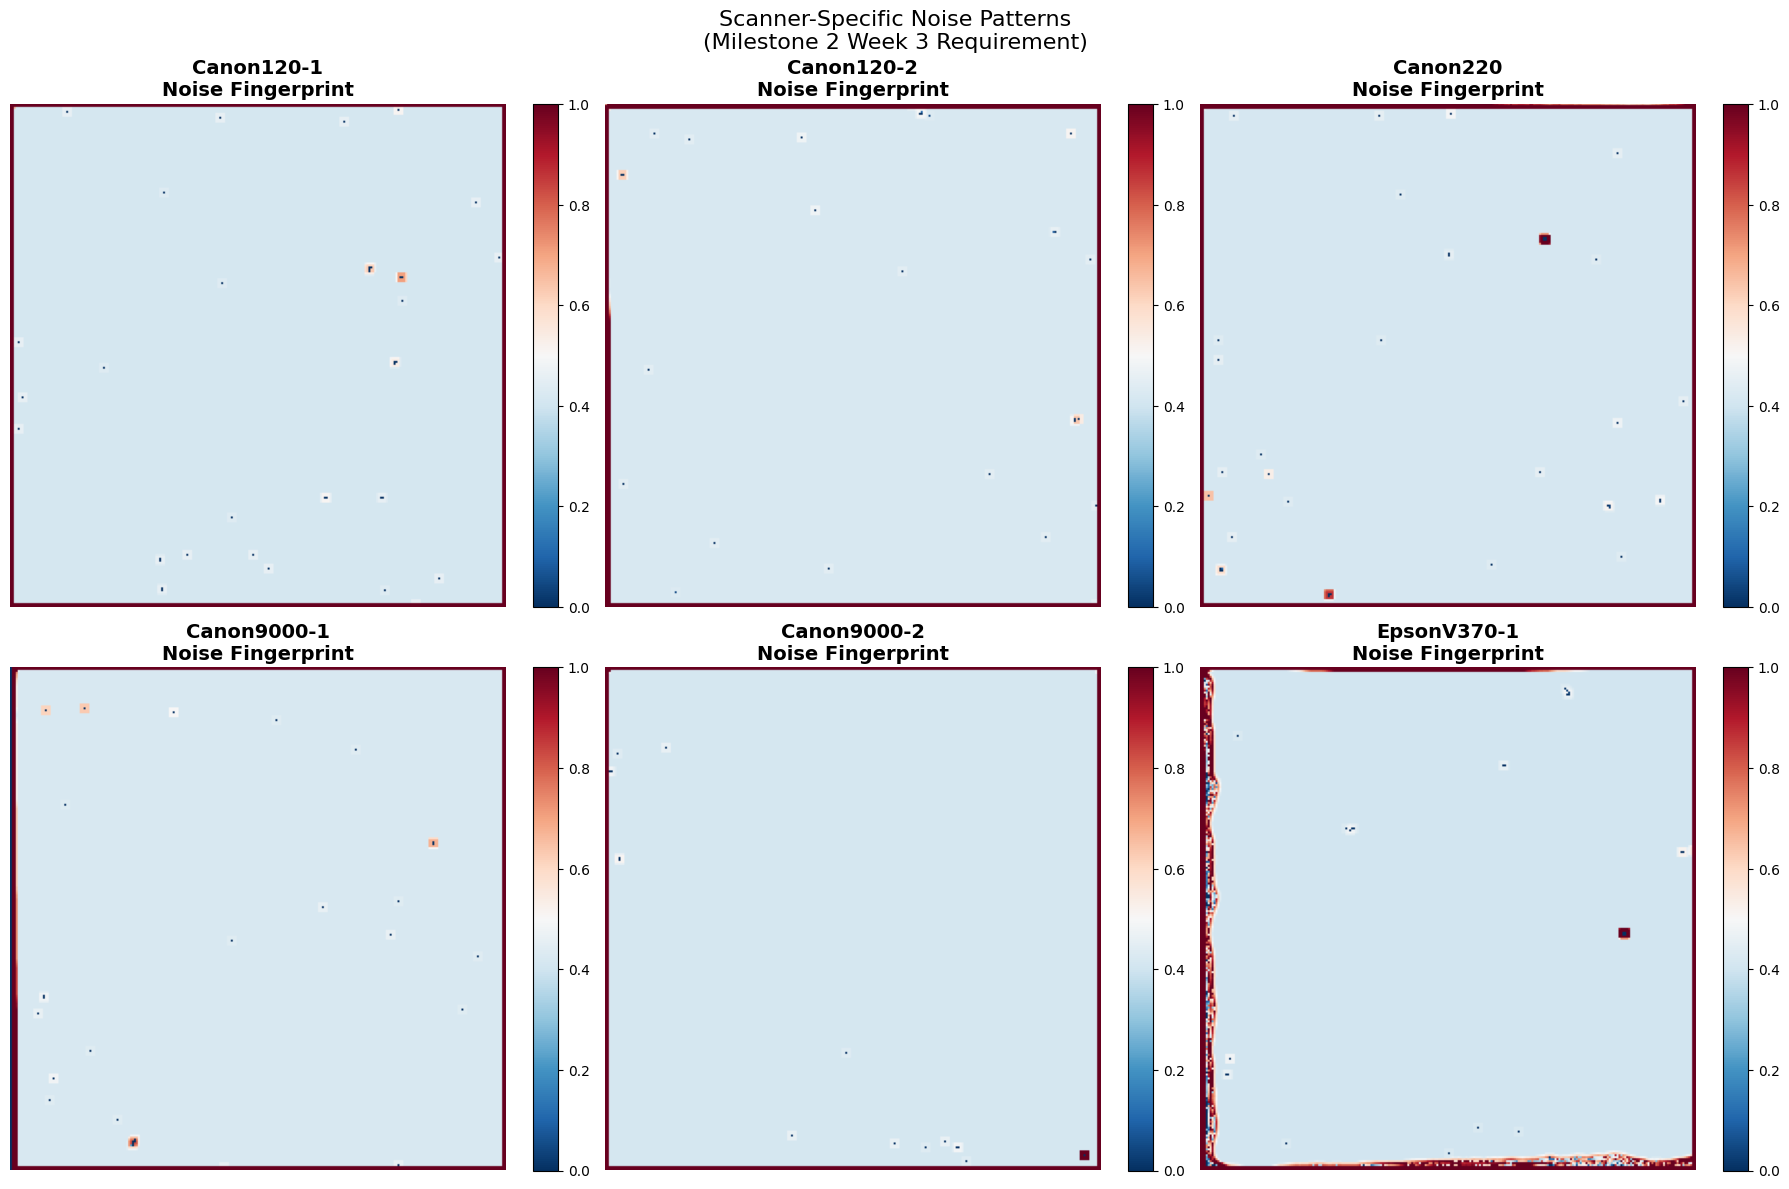

✅ Scanner noise visualization complete - Milestone 2 Week 3 ✅


In [18]:
import os, pickle, numpy as np, matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
METRICS_DIR = os.path.join(FEATURES_DIR, "metrics")
os.makedirs(METRICS_DIR, exist_ok=True)

FP_PATH = os.path.join(FEATURES_DIR, "scanner_fingerprints.pkl")

with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

scanners = list(scanner_fps.keys())[:6]

for i, scanner in enumerate(scanners):
    fp = scanner_fps[scanner].astype(np.float32)

    # Baseline z-score visualization
    fp_enhanced = (fp - fp.mean()) / (fp.std() + 1e-8) * 0.5 + 0.5
    fp_clipped = np.clip(fp_enhanced, 0, 1)

    im = axes[i].imshow(fp_clipped, cmap="RdBu_r", aspect="auto")
    axes[i].set_title(f"{scanner}\nNoise Fingerprint", fontsize=14, fontweight="bold")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle("Scanner-Specific Noise Patterns\n(Milestone 2 Week 3 Requirement)", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIR, "scanner_noise_maps.png"), dpi=300, bbox_inches="tight")
plt.show()

print("✅ Scanner noise visualization complete - Milestone 2 Week 3 ✅")


Loads scanner fingerprints and a fixed scanner key order to ensure consistent feature vector layout.

Defines corr2d to compute zero-mean normalized cross-correlation (ZNCC) between an image residual and each fingerprint.

Loads precomputed residuals for Official and Wikipedia and iterates by scanner and DPI.

For every residual image, builds a feature vector as correlations to all fingerprints in fp_keys order and records the corresponding scanner label.

Saves features and labels to features.pkl and prints the resulting matrix shape.

In [19]:

import os
import pickle
import numpy as np
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")

RES_PATH = os.path.join(FEATURES_DIR, "official_wiki_residuals.pkl")
FP_PATH = os.path.join(FEATURES_DIR, "scanner_fingerprints.pkl")
ORDER_PATH = os.path.join(FEATURES_DIR, "fp_keys.npy")
OUT_PATH = os.path.join(FEATURES_DIR, "features.pkl")

with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)

fp_keys = np.load(ORDER_PATH, allow_pickle=True).tolist()

def corr2d(a, b):
    h = min(a.shape[0], b.shape[0])
    w = min(a.shape[1], b.shape[1])
    a = a[:h, :w].astype(np.float32).ravel()
    b = b[:h, :w].astype(np.float32).ravel()
    a -= a.mean()
    b -= b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float((a @ b) / denom) if denom != 0 else 0.0

with open(RES_PATH, "rb") as f:
    residuals_dict = pickle.load(f)

features = []
labels = []

for dataset in ["Official", "Wikipedia"]:
    for scanner, dpi_dict in tqdm(residuals_dict[dataset].items()):
        for res_list in dpi_dict.values():
            for res in res_list:
                vec = [corr2d(res, scanner_fps[k]) for k in fp_keys]
                features.append(vec)
                labels.append(scanner)

with open(OUT_PATH, "wb") as f:
    pickle.dump({"features": features, "labels": labels}, f)

print("Saved correlation features:", OUT_PATH)
print("Shape:", len(features), "x", len(features[0]) if features else 0)


100%|██████████| 11/11 [00:06<00:00,  1.73it/s]

Saved correlation features: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/features.pkl
Shape: 4568 x 11


Extracted the enhanced features (FFT + LBP + Texture)

In [20]:
import os
import pickle
import numpy as np
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from scipy import ndimage
from scipy.fft import fft2, fftshift

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")

RES_PATH = os.path.join(FEATURES_DIR, "official_wiki_residuals.pkl")
OUT_PATH = os.path.join(FEATURES_DIR, "enhanced_features.pkl")

with open(RES_PATH, "rb") as f:
    residuals_dict = pickle.load(f)

def extract_features(res):
    res = res.astype(np.float32)

    fft_img = np.abs(fftshift(fft2(res)))
    h, w = fft_img.shape
    ch, cw = h // 2, w // 2

    low = fft_img[ch-20:ch+20, cw-20:cw+20].mean()
    mid = fft_img[ch-60:ch+60, cw-60:cw+60].mean() - low
    high = fft_img.mean() - low - mid

    rng = np.ptp(res)
    if rng < 1e-12:
        res_n = np.zeros_like(res, dtype=np.uint8)
    else:
        res_n = ((res - res.min()) / (rng + 1e-8) * 255.0).astype(np.uint8)

    lbp = local_binary_pattern(res_n, P=8, R=1.0, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

    gx = ndimage.sobel(res, axis=1)
    gy = ndimage.sobel(res, axis=0)
    gmag = np.sqrt(gx**2 + gy**2)

    texture = [
        float(np.std(res)),
        float(np.mean(np.abs(res))),
        float(np.std(gmag)),
        float(np.mean(gmag)),
    ]

    return [low, mid, high] + lbp_hist.tolist() + texture

features = []
labels = []

for dataset in ["Official", "Wikipedia"]:
    for scanner, dpi_dict in tqdm(residuals_dict[dataset].items()):
        for res_list in dpi_dict.values():
            for res in res_list:
                features.append(extract_features(res))
                labels.append(scanner)

with open(OUT_PATH, "wb") as f:
    pickle.dump({"features": features, "labels": labels}, f)

print("Saved enhanced features:", OUT_PATH)
print("Shape:", len(features), "x", len(features[0]) if features else 0)


100%|██████████| 11/11 [00:42<00:00,  3.84s/it]

Saved enhanced features: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/enhanced_features.pkl
Shape: 4568 x 17


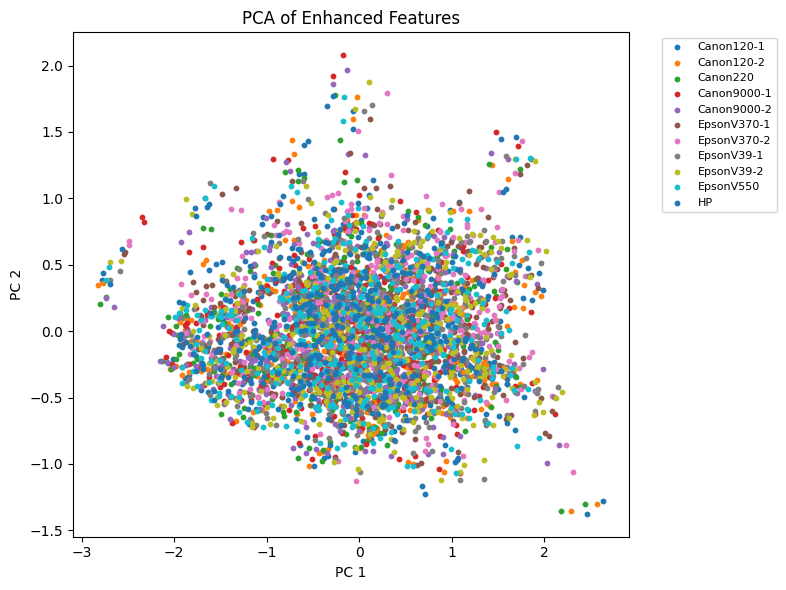

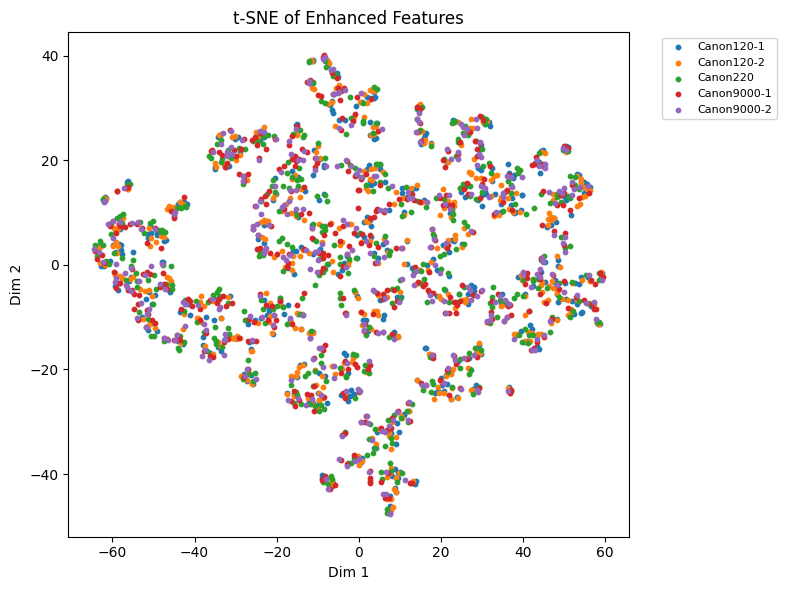

Feature visualizations saved in metrics folder.


In [21]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
METRICS_DIR = os.path.join(FEATURES_DIR, "metrics")
os.makedirs(METRICS_DIR, exist_ok=True)

FEAT_PATH = os.path.join(FEATURES_DIR, "enhanced_features.pkl")

with open(FEAT_PATH, "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"], dtype=np.float32)
y = np.array(data["labels"])

order = np.argsort(y)
X = X[order]
y = y[order]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for label in np.unique(y):
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=10, label=label)

plt.title("PCA of Enhanced Features")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIR, "pca_features.png"), dpi=300)
plt.show()

n_tsne = min(2000, len(X))
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X[:n_tsne])
y_tsne = y[:n_tsne]

plt.figure(figsize=(8, 6))
for label in np.unique(y_tsne):
    idx = y_tsne == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=10, label=label)

plt.title("t-SNE of Enhanced Features")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIR, "tsne_features.png"), dpi=300)
plt.show()

print("Feature visualizations saved in metrics folder.")


# Milestone 3 — Deep model + explainability

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.2356 - loss: 1.9445 - val_accuracy: 0.3260 - val_loss: 1.6462


Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.2972 - loss: 1.6561 - val_accuracy: 0.2462 - val_loss: 1.7268


Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.3292 - loss: 1.5974 - val_accuracy: 0.3359 - val_loss: 1.5491


Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.3374 - loss: 1.5661 - val_accuracy: 0.3512 - val_loss: 1.5019


Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.3799 - loss: 1.4160 - val_accuracy: 0.3939 - val_loss: 1.3509


...

Epoch 46/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.9480 - loss: 0.1371 - val_accuracy: 0.9519 - val_loss: 0.1419


Epoch 47/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.9513 - loss: 0.1324 - val_accuracy: 0.9683 - val_loss: 0.0907


Epoch 48/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.9469 - loss: 0.1516 - val_accuracy: 0.9365 - val_loss: 0.1600


Epoch 49/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.9510 - loss: 0.1233 - val_accuracy: 0.9519 - val_loss: 0.1341


Epoch 50/50
115/115 ━━━━━━━━━━━━━━━━━━━━ accuracy: 0.9510 - loss: 0.1470 - val_accuracy: 0.9573 - val_loss: 0.1341


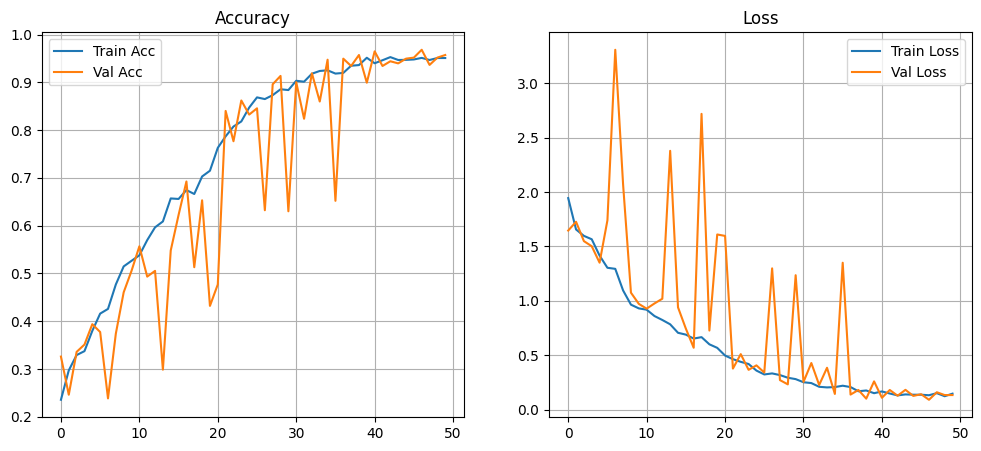


Classification Report

              precision    recall  f1-score   support

  Canon120-1       0.93      0.84      0.89        83
  Canon120-2       0.92      0.95      0.93        83
    Canon220       0.88      0.99      0.93        83
 Canon9000-1       0.97      0.92      0.94        83
 Canon9000-2       0.92      0.98      0.95        82
 EpsonV370-1       1.00      0.98      0.99        83
 EpsonV370-2       0.98      1.00      0.99        84
  EpsonV39-1       0.94      0.98      0.96        83
  EpsonV39-2       1.00      0.90      0.95        84
   EpsonV550       1.00      1.00      1.00        83
          HP       1.00      1.00      1.00        83

    accuracy                           0.96       914
   macro avg       0.96      0.96      0.96       914
weighted avg       0.96      0.96      0.96       914



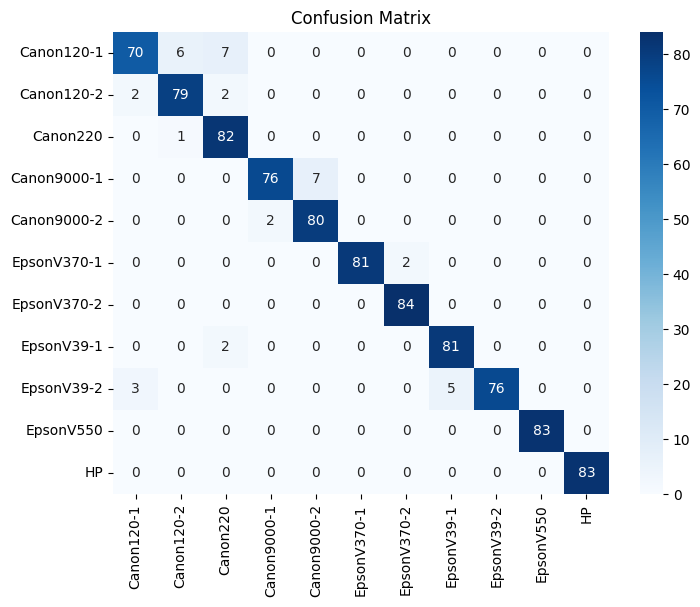

In [22]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- PATHS ----------------
BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
MODELS_DIR = os.path.join(FEATURES_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# ---------------- LOAD DATA ----------------
with open(os.path.join(FEATURES_DIR, "official_wiki_residuals.pkl"), "rb") as f:
    residuals_dict = pickle.load(f)

with open(os.path.join(FEATURES_DIR, "enhanced_features.pkl"), "rb") as f:
    feat_data = pickle.load(f)

X_feat = np.array(feat_data["features"], dtype=np.float32)
labels = np.array(feat_data["labels"])

X_img, y = [], []
for dataset in ["Official", "Wikipedia"]:
    for scanner, dpi_dict in residuals_dict[dataset].items():
        for res_list in dpi_dict.values():
            for res in res_list:
                X_img.append(res[None, :, :])   # (1, H, W)
                y.append(scanner)

X_img = np.array(X_img, dtype=np.float32)
y = np.array(y)

classes = sorted(np.unique(y))
class_map = {c: i for i, c in enumerate(classes)}
y_enc = np.array([class_map[v] for v in y])

Xi_tr, Xi_te, Xf_tr, Xf_te, y_tr, y_te = train_test_split(
    X_img, X_feat, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
Xf_tr = scaler.fit_transform(Xf_tr)
Xf_te = scaler.transform(Xf_te)

# ---------------- DATASET ----------------
class HybridDataset(Dataset):
    def __init__(self, imgs, feats, labels):
        self.imgs = torch.tensor(imgs, dtype=torch.float32)
        self.feats = torch.tensor(feats, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.imgs[idx], self.feats[idx], self.labels[idx]

train_loader = DataLoader(HybridDataset(Xi_tr, Xf_tr, y_tr), batch_size=32, shuffle=True)
test_loader  = DataLoader(HybridDataset(Xi_te, Xf_te, y_te), batch_size=32, shuffle=False)

# ---------------- MODEL ----------------
class HybridCNN(nn.Module):
    def __init__(self, num_classes, feat_dim):
        super().__init__()

        hp_kernel = torch.tensor(
            [[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]],
            dtype=torch.float32
        ).unsqueeze(0)

        self.hp = nn.Conv2d(1, 1, 3, padding=1, bias=False)
        self.hp.weight.data = hp_kernel
        self.hp.weight.requires_grad = False

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.30),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.feat_fc = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, feat):
        x = self.hp(img)
        x = self.cnn(x).view(x.size(0), -1)
        f = self.feat_fc(feat)
        return self.classifier(torch.cat([x, f], dim=1))

# ---------------- TRAIN ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCNN(len(classes), Xf_tr.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 50
best_acc = 0.0

train_accs, val_accs = [], []
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    tr_loss, yt, yp = 0.0, [], []

    for img, feat, lbl in tqdm(train_loader, leave=False):
        img, feat, lbl = img.to(device), feat.to(device), lbl.to(device)

        optimizer.zero_grad()
        out = model(img, feat)
        loss = criterion(out, lbl)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item()
        yt.extend(lbl.cpu().numpy())
        yp.extend(out.argmax(1).cpu().numpy())

    tr_loss /= len(train_loader)
    tr_acc = accuracy_score(yt, yp)

    model.eval()
    vl_loss, yt_v, yp_v = 0.0, [], []
    with torch.no_grad():
        for img, feat, lbl in test_loader:
            img, feat, lbl = img.to(device), feat.to(device), lbl.to(device)
            out = model(img, feat)
            loss = criterion(out, lbl)
            vl_loss += loss.item()
            yt_v.extend(lbl.cpu().numpy())
            yp_v.extend(out.argmax(1).cpu().numpy())

    vl_loss /= len(test_loader)
    vl_acc = accuracy_score(yt_v, yp_v)

    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}\n"
        f"{len(train_loader)}/{len(train_loader)} ━━━━━━━━━━━━━━━━━━━━ "
        f"accuracy: {tr_acc:.4f} - loss: {tr_loss:.4f} "
        f"- val_accuracy: {vl_acc:.4f} - val_loss: {vl_loss:.4f}"
    )

    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, "hybrid_cnn.pth"))

# ---------------- SAVE EXTRAS ----------------
with open(os.path.join(MODELS_DIR, "hybrid_scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODELS_DIR, "class_map.pkl"), "wb") as f:
    pickle.dump(classes, f)

# ---------------- GRAPHS ----------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend(); plt.grid(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.grid(); plt.title("Loss")
plt.show()

# ---------------- REPORT + CM ----------------
print("\nClassification Report\n")
print(classification_report(yt_v, yp_v, target_names=classes))

cm = confusion_matrix(yt_v, yp_v)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.show()


In [34]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import cv2
import pywt
from skimage.feature import local_binary_pattern
from scipy import ndimage
from scipy.fft import fft2, fftshift

print("✅ Loaded fingerprints, fixed key order, and PyTorch model.")

# ---------------- PATHS ----------------
BASE_DIR = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
FEATURES_DIR = os.path.join(BASE_DIR, "Features")
MODELS_DIR   = os.path.join(FEATURES_DIR, "models")

OFFICIAL_DIR  = os.path.join(BASE_DIR, "OfficialData")
WIKIPEDIA_DIR = os.path.join(BASE_DIR, "WikipediaData")

# ---------------- RESIDUAL ----------------
def compute_residual(img):
    cA, (cH, cV, cD) = pywt.dwt2(img, 'haar')
    cH.fill(0); cV.fill(0); cD.fill(0)
    den = pywt.idwt2((cA, (cH, cV, cD)), 'haar')
    return (img - den).astype(np.float32)

def preprocess_residual_pywt(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        print(f"⚠️ Could not read image: {path}")
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    return compute_residual(img)

# ---------------- FEATURE EXTRACTION ----------------
def make_feats_from_res(res):
    fft_img = np.abs(fftshift(fft2(res)))
    h, w = fft_img.shape
    ch, cw = h // 2, w // 2

    low  = fft_img[ch-20:ch+20, cw-20:cw+20].mean()
    mid  = fft_img[ch-60:ch+60, cw-60:cw+60].mean() - low
    high = fft_img.mean() - low - mid

    rng = np.ptp(res)
    if rng < 1e-12:
        res_n = np.zeros_like(res, dtype=np.uint8)
    else:
        res_n = ((res - res.min()) / (rng + 1e-8) * 255.0).astype(np.uint8)

    lbp = local_binary_pattern(res_n, P=8, R=1.0, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

    gx = ndimage.sobel(res, axis=1)
    gy = ndimage.sobel(res, axis=0)
    gmag = np.sqrt(gx**2 + gy**2)

    feats = [low, mid, high] + lbp_hist.tolist() + [
        float(np.std(res)),
        float(np.mean(np.abs(res))),
        float(np.std(gmag)),
        float(np.mean(gmag)),
    ]

    feats = scaler_inf.transform(np.array(feats).reshape(1, -1))
    return torch.tensor(feats, dtype=torch.float32)

# ---------------- MODEL ----------------
class HybridCNN(nn.Module):
    def __init__(self, num_classes, feat_dim):
        super().__init__()

        hp_kernel = torch.tensor(
            [[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]],
            dtype=torch.float32
        ).unsqueeze(0)

        self.hp = nn.Conv2d(1, 1, 3, padding=1, bias=False)
        self.hp.weight.data = hp_kernel
        self.hp.weight.requires_grad = False

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.30),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.feat_fc = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, feat):
        x = self.hp(img)
        x = self.cnn(x).view(x.size(0), -1)
        f = self.feat_fc(feat)
        return self.classifier(torch.cat([x, f], dim=1))

# ---------------- LOAD ARTIFACTS ----------------
device = "cuda" if torch.cuda.is_available() else "cpu"

with open(os.path.join(MODELS_DIR, "hybrid_scaler.pkl"), "rb") as f:
    scaler_inf = pickle.load(f)

with open(os.path.join(MODELS_DIR, "class_map.pkl"), "rb") as f:
    scanner_classes = pickle.load(f)

model = HybridCNN(len(scanner_classes), scaler_inf.mean_.shape[0]).to(device)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "hybrid_cnn.pth"), map_location=device))
model.eval()

# ---------------- TEST ----------------
test_paths = [
    # Official
    os.path.join(OFFICIAL_DIR, "Canon120-1/150/s1_60.tif"),
    os.path.join(OFFICIAL_DIR, "Canon120-2/300/s2_40.tif"),
    os.path.join(OFFICIAL_DIR, "Canon220/150/s3_25.tif"),
    os.path.join(OFFICIAL_DIR, "Canon9000-1/300/s4_75.tif"),
    os.path.join(OFFICIAL_DIR, "Canon9000-2/150/s5_10.tif"),
    os.path.join(OFFICIAL_DIR, "EpsonV370-1/300/s6_60.tif"),
    os.path.join(OFFICIAL_DIR, "HP/150/s11_60.tif"),

    # Wikipedia
    os.path.join(WIKIPEDIA_DIR, "Canon120-1/300/s1_5.tif"),
    os.path.join(WIKIPEDIA_DIR, "Canon220/150/s3_1.tif"),
    os.path.join(WIKIPEDIA_DIR, "Canon9000-1/300/s4_5.tif"),
    os.path.join(WIKIPEDIA_DIR, "EpsonV39-2/150/s9_66.tif"),
    os.path.join(WIKIPEDIA_DIR, "HP/150/s11_1.tif"),
    os.path.join(WIKIPEDIA_DIR, "EpsonV370-1/300/s6_60.tif"),
    os.path.join(WIKIPEDIA_DIR, "HP/150/s11_60.tif"),
]
for p in test_paths:
    res = preprocess_residual_pywt(p)
    if res is None:
        continue

    x_img = torch.tensor(res).unsqueeze(0).unsqueeze(0).to(device)
    x_ft  = make_feats_from_res(res).to(device)

    with torch.no_grad():
        logits = model(x_img, x_ft)
        prob = torch.softmax(logits, dim=1).cpu().numpy().ravel()

    idx = int(prob.argmax())
    print(f"{p} -> {scanner_classes[idx]} | {prob[idx]*100:.2f}%")


✅ Loaded fingerprints, fixed key order, and PyTorch model.
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/Canon120-1/150/s1_60.tif -> Canon120-1 | 95.00%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/Canon120-2/300/s2_40.tif -> Canon120-2 | 98.97%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/Canon220/150/s3_25.tif -> Canon220 | 98.35%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/Canon9000-1/300/s4_75.tif -> Canon9000-1 | 99.28%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/Canon9000-2/150/s5_10.tif -> Canon9000-2 | 83.97%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/EpsonV370-1/300/s6_60.tif -> EpsonV370-1 | 99.98%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/OfficialData/HP/150/s11_60.tif -> HP | 100.00%
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/WikipediaData/Canon120-1/300/s1_5.tif -> Canon120-1 | 

In [4]:
print("🔹 Loading trained artifacts from Google Drive")

# ===== Drive Paths (UNCHANGED) =====
model_path  = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/models/hybrid_cnn.pth"
classes_path= "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/models/class_map.pkl"
scaler_path = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/models/hybrid_scaler.pkl"
fps_path    = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/scanner_fingerprints.pkl"
keys_path   = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Features/fp_keys.npy"

# ===== Load artifacts =====
with open(classes_path, "rb") as f:
    classes = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler_inf = pickle.load(f)

with open(fps_path, "rb") as f:
    scanner_fps_inf = pickle.load(f)

fp_keys_inf = np.load(keys_path, allow_pickle=True).tolist()

# ===== Load  model =====
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HybridCNN(num_classes=len(classes), feat_dim=scaler_inf.mean_.shape[0])
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("✅ Loaded everything successfully")
print("Classes:", classes)
print("FP order:", fp_keys_inf)


torch.save(model.state_dict(), "/content/scanner_hybrid.pth")

with open("/content/hybrid_classes.pkl", "wb") as f:
    pickle.dump(classes, f)

with open("/content/hybrid_feat_scaler.pkl", "wb") as f:
    pickle.dump(scaler_inf, f)

with open("/content/scanner_fingerprints.pkl", "wb") as f:
    pickle.dump(scanner_fps_inf, f)

np.save("/content/fp_keys.npy", np.array(fp_keys_inf, dtype=object))

print("\n✅ EXPORT COMPLETE (PyTorch)")
print("Files saved in /content:")
print(" - scanner_hybrid.pth")
print(" - hybrid_classes.pkl")
print(" - hybrid_feat_scaler.pkl")
print(" - scanner_fingerprints.pkl")
print(" - fp_keys.npy")


🔹 Loading trained artifacts from Google Drive
✅ Loaded everything successfully
Classes: [np.str_('Canon120-1'), np.str_('Canon120-2'), np.str_('Canon220'), np.str_('Canon9000-1'), np.str_('Canon9000-2'), np.str_('EpsonV370-1'), np.str_('EpsonV370-2'), np.str_('EpsonV39-1'), np.str_('EpsonV39-2'), np.str_('EpsonV550'), np.str_('HP')]
FP order: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2', 'EpsonV370-1', 'EpsonV370-2', 'EpsonV39-1', 'EpsonV39-2', 'EpsonV550', 'HP']

✅ EXPORT COMPLETE (PyTorch)
Files saved in /content:
 - scanner_hybrid.pth
 - hybrid_classes.pkl
 - hybrid_feat_scaler.pkl
 - scanner_fingerprints.pkl
 - fp_keys.npy


In [5]:
from google.colab import files

print("⬇ Downloading exported artifacts...")

files.download("/content/scanner_hybrid.pth")
files.download("/content/hybrid_classes.pkl")
files.download("/content/hybrid_feat_scaler.pkl")
files.download("/content/scanner_fingerprints.pkl")
files.download("/content/fp_keys.npy")
print(" All files downloaded successfully")


⬇ Downloading exported artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 All files downloaded successfully


# Objective 2: Forgery Detection

Installed PyMuPDF

Imported libraries for files, images, PDFs, ML

Set random seed (42) for reproducibility

In [6]:
!pip -q install pymupdf

import os, glob, csv, pickle, random
from pathlib import Path
import numpy as np
import cv2, pywt
from PIL import Image
from tqdm import tqdm
import fitz  # PyMuPDF

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from skimage.feature import local_binary_pattern as sk_lbp

SEED = 42
random.seed(SEED); np.random.seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 82.9 MB/s eta 0:00:00


Set root project path.

Defined paths for original PDFs and their TIFF outputs.

Defined paths for tampered images (Original, Copy-move, Retouching, Splicing).

Defined paths for artifacts and manifest CSV.

Created required output folders if they don’t exist.

In [7]:
# ROOT
ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"

#  ORIGINAL PDFs
ORIG_PDF_OFF = f"{ROOT}/OriginalData/official"
ORIG_PDF_WIK = f"{ROOT}/OriginalData/wikipedia"

# CONVERTED TIFF OUTPUT
CONV_OUT = f"{ROOT}/Originals_tif"
os.makedirs(CONV_OUT, exist_ok=True)

# TAMPERED DATA
TAMP_ROOT     = f"{ROOT}/TamperedData"
TAMP_ORIG_TIF = f"{TAMP_ROOT}/Original"
TAMP_COPY_TIF = f"{TAMP_ROOT}/Tampered/Copy-move"
TAMP_RETO_TIF = f"{TAMP_ROOT}/Tampered/Retouching"
TAMP_SPLI_TIF = f"{TAMP_ROOT}/Tampered/Splicing"

# ARTIFACTS / MANIFEST
ART_DIR      = f"{ROOT}/artifacts_tamper"
MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest.csv"
os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(os.path.dirname(MANIFEST_CSV), exist_ok=True)

Created a function to convert each PDF page into TIFF images (300 DPI).

Ensured RGB format and applied TIFF compression.

Built a batch function to find all PDFs in official and wikipedia folders.

Organized outputs into corresponding subfolders.

Ran the batch conversion with progress bar and error handling.

In [8]:
def pdf_to_tiffs(pdf_path, out_dir, dpi=300):
    os.makedirs(out_dir, exist_ok=True)
    doc = fitz.open(pdf_path)

    for i, page in enumerate(doc):
        pix = page.get_pixmap(dpi=dpi)
        mode = "RGB" if pix.alpha == 0 else "RGBA"

        img = Image.frombytes(mode, [pix.width, pix.height], pix.samples)
        if img.mode != "RGB":
            img = img.convert("RGB")

        stem = Path(pdf_path).stem
        out_path = f"{out_dir}/{stem}_p{i+1}.tif"
        img.save(out_path, format="TIFF", dpi=(dpi, dpi), compression="tiff_deflate")

    doc.close()


In [9]:
def batch_convert_originals():
    tasks = []

    for sub in ["official", "wikipedia"]:
        src_root = f"{ROOT}/OriginalData/{sub}"   # correct source
        dst_root = f"{CONV_OUT}/{sub}"
        os.makedirs(dst_root, exist_ok=True)

        for pdf in glob.glob(f"{src_root}/**/*.pdf", recursive=True):
            parent = Path(pdf).parent.name
            out_dir = f"{dst_root}/{parent}"
            tasks.append((pdf, out_dir))

    print("Total PDFs found:", len(tasks))

    for pdf, outd in tqdm(tasks, desc="PDF→TIFF 300dpi"):
        try:
            pdf_to_tiffs(pdf, outd, dpi=300)
        except Exception as e:
            print("Failed:", pdf, "->", e)

# Run conversion
batch_convert_originals()


Total PDFs found: 208


PDF→TIFF 300dpi: 100%|██████████| 208/208 [09:01<00:00,  2.61s/it]


After converting original PDFs into TIFF pages, we define the final dataset paths for:

- **Genuine TIFF samples**
  - `Originals_tif/official`
  - `Originals_tif/wikipedia`

In [10]:
ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"

# Converted Originals (TIFF)
ORIG_TIF_OFF = f"{ROOT}/Originals_tif/official"
ORIG_TIF_WIK = f"{ROOT}/Originals_tif/wikipedia"

# Tampered Data
TAMP_ROOT    = f"{ROOT}/TamperedData"
TAMP_ORIG_TF = f"{TAMP_ROOT}/Original"
TAMP_CM_TF   = f"{TAMP_ROOT}/Tampered/Copy-move"
TAMP_RT_TF   = f"{TAMP_ROOT}/Tampered/Retouching"
TAMP_SP_TF   = f"{TAMP_ROOT}/Tampered/Splicing"


 **Tampered dataset samples**
  - Copy-move
  - Retouching
  - Splicing

This standardized folder structure allows us to build a binary forgery detection dataset.

In [11]:
import os, glob, csv, re
from pathlib import Path

MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest_grouped.csv"
os.makedirs(os.path.dirname(MANIFEST_CSV), exist_ok=True)

def list_tifs(root):
    if not os.path.exists(root):
        print("Missing:", root)
        return []
    return sorted([
        p for p in glob.glob(f"{root}/**/*", recursive=True)
        if p.lower().endswith((".tif", ".tiff"))
    ])

def infer_page_id(p):
    # Works for both _p1 and dataset style names
    name = os.path.basename(p)
    m = re.search(r"(s\d+_\d+)", name)
    if m:
        return m.group(1)
    stem = Path(p).stem
    stem = re.sub(r"_p\d+$", "", stem)
    return stem

rows = [["path","label","domain","tamper_type","page_id"]]

for p in list_tifs(ORIG_TIF_OFF):
    rows.append([p, 0, "orig_pdf_tif", "clean", infer_page_id(p)])

for p in list_tifs(ORIG_TIF_WIK):
    rows.append([p, 0, "orig_pdf_tif", "clean", infer_page_id(p)])

for p in list_tifs(TAMP_ORIG_TF):
    rows.append([p, 0, "tamper_dir", "clean", infer_page_id(p)])

for p in list_tifs(TAMP_CM_TF):
    rows.append([p, 1, "tamper_dir", "copy-move", infer_page_id(p)])

for p in list_tifs(TAMP_RT_TF):
    rows.append([p, 1, "tamper_dir", "retouch", infer_page_id(p)])

for p in list_tifs(TAMP_SP_TF):
    rows.append([p, 1, "tamper_dir", "splice", infer_page_id(p)])

with open(MANIFEST_CSV, "w", newline="") as fh:
    csv.writer(fh).writerows(rows)

print("Wrote manifest:", MANIFEST_CSV)
print("Total rows:", len(rows)-1)


Wrote manifest: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/manifests/tamper_manifest_grouped.csv
Total rows: 344


In this section, we extract local forgery artifacts using a **wavelet residual** representation and build a patch-level dataset.

### Why Residual?
Residual images emphasize:
- scanner/compression noise
- subtle manipulation traces
- abnormal texture inconsistencies

###  Residual Generation + Patch Extraction
- Each TIFF image is converted to grayscale and resized to `256 × 256`
- Haar DWT denoising is applied and residual is computed:
  **Residual = Original − Denoised**
- Residual image is split into patches:
  - Patch size = 128 × 128
  - Stride = 64
  - Max patches/image = 16


In [12]:
import numpy as np, cv2, pywt, math
from skimage.feature import local_binary_pattern as sk_lbp

IMG_SIZE = (256,256)
PATCH = 128
STRIDE = 64
MAX_PATCHES = 16

def load_to_residual(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")

    # Handle multi-channel TIFF safely
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    # Haar DWT denoising residual
    cA, (cH, cV, cD) = pywt.dwt2(img, "haar")
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    den = pywt.idwt2((cA, (cH, cV, cD)), "haar")

    return (img - den).astype(np.float32)

def extract_patches(res, patch=PATCH, stride=STRIDE, limit=MAX_PATCHES, seed=42):
    H, W = res.shape
    if H < patch or W < patch:
        return []

    ys = list(range(0, H - patch + 1, stride))
    xs = list(range(0, W - patch + 1, stride))
    coords = [(y, x) for y in ys for x in xs]

    rng = np.random.RandomState(seed)
    rng.shuffle(coords)
    coords = coords[:min(limit, len(coords))]

    return [res[y:y+patch, x:x+patch] for y, x in coords]


###  Hand-Crafted Feature Extraction (Patch-Level)
For every residual patch, we compute a compact **22-dimensional feature vector**:

 **LBP Histogram (10 bins):** captures texture irregularities  
 **FFT Radial Energy (6 bins):** captures frequency-domain artifacts  
 **Residual Statistics (3):** mean, std, mean(|x|)  
 **FFT Resampling Features (3):** frequency band energies + ratio  

These features are designed to detect tampering traces even when they are visually subtle.


In [13]:
def lbp_hist_safe(img, P=8, R=1.0):
    rng = float(np.ptp(img))
    if rng < 1e-12:
        g = np.zeros_like(img, dtype=np.float32)
    else:
        g = (img - float(np.min(img))) / (rng + 1e-8)

    g8 = np.clip(g * 255.0, 0, 255).astype(np.uint8)
    codes = sk_lbp(g8, P=P, R=R, method="uniform")
    n_bins = P + 2
    hist, _ = np.histogram(codes, bins=np.arange(n_bins+1), density=True)
    return np.nan_to_num(hist, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def fft_radial_energy(img, K=6):
    f = np.fft.fftshift(np.fft.fft2(img))
    mag = np.abs(f)
    h,w = mag.shape
    cy,cx = h//2, w//2
    yy,xx = np.ogrid[:h,:w]
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    bins = np.linspace(0, r.max()+1e-6, K+1)

    feats=[]
    for i in range(K):
        m = (r>=bins[i]) & (r<bins[i+1])
        feats.append(float(mag[m].mean() if m.any() else 0.0))

    return np.asarray(feats, dtype=np.float32)

def residual_stats(img):
    return np.asarray([
        float(np.mean(img)),
        float(np.std(img)),
        float(np.mean(np.abs(img)))
    ], dtype=np.float32)

def fft_resample_feats(img):
    f = np.fft.fftshift(np.fft.fft2(img))
    mag = np.abs(f)
    h,w = mag.shape
    cy,cx = h//2, w//2
    yy,xx = np.ogrid[:h,:w]
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = r.max() + 1e-6

    b1 = (r>=0.25*rmax) & (r<0.35*rmax)
    b2 = (r>=0.35*rmax) & (r<0.50*rmax)

    e1 = float(mag[b1].mean() if b1.any() else 0.0)
    e2 = float(mag[b2].mean() if b2.any() else 0.0)
    ratio = float(e2 / (e1 + 1e-8))

    return np.asarray([e1, e2, ratio], dtype=np.float32)

def make_feat_vector(img_patch):
    lbp = lbp_hist_safe(img_patch, 8, 1.0)   # 10
    fft6 = fft_radial_energy(img_patch, 6)   # 6
    res3 = residual_stats(img_patch)         # 3
    rsp3 = fft_resample_feats(img_patch)     # 3
    return np.concatenate([lbp, fft6, res3, rsp3], axis=0)  # = 22 features


###  Patch Dataset Construction + Train/Validation Split
To prevent data leakage, we perform:
- **StratifiedGroupKFold split**
- Group key = `page_id`
  (ensures patches from the same page do not appear in both train & validation)

Additional debiasing:
- Balanced clean samples from:
  - original PDF converted TIFFs (`orig_pdf_tif`)
  - clean pages inside tamper dataset (`tamper_dir`)
- Light augmentation applied only to clean samples from `tamper_dir` to reduce domain bias.

Finally, feature scaling is applied using:
 `StandardScaler`


In [14]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import csv

with open(MANIFEST_CSV, "r") as fh:
    rr = list(csv.DictReader(fh))

paths  = np.array([r["path"] for r in rr], dtype=object)
labels = np.array([int(r["label"]) for r in rr], dtype=np.int64)
groups = np.array([r["page_id"] for r in rr], dtype=object)
domain = np.array([r["domain"] for r in rr], dtype=object)
ttype  = np.array([r["tamper_type"] for r in rr], dtype=object)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, va_idx = next(sgkf.split(paths, labels, groups))

# Augmentation
def augment_patch(p):
    a = p + 0.003 * np.random.randn(*p.shape)
    if np.random.rand() < 0.5:
        a = cv2.GaussianBlur(a, (3,3), 0)
    return np.clip(a, 0.0, 1.0).astype(np.float32)

# Patch Builder
def build_patchset(idxs, balance_clean_domains=True, seed=42, aug_clean_tdir=True):
    Xp, yp, dp, tp, gp, ip = [], [], [], [], [], []
    rng = np.random.RandomState(seed)

    idxs = list(idxs)
    idxs_clean = [i for i in idxs if labels[i]==0]
    idxs_clean_orig = [i for i in idxs_clean if domain[i]=="orig_pdf_tif"]
    idxs_clean_tdir = [i for i in idxs_clean if domain[i]=="tamper_dir"]

    if balance_clean_domains and idxs_clean_orig and idxs_clean_tdir:
        cap = min(len(idxs_clean_orig), len(idxs_clean_tdir))
        rng.shuffle(idxs_clean_orig); rng.shuffle(idxs_clean_tdir)
        idxs_use = idxs_clean_orig[:cap] + idxs_clean_tdir[:cap] + [i for i in idxs if labels[i]==1]
    else:
        idxs_use = idxs

    for i in tqdm(idxs_use, desc="patchify+debias"):
        try:
            res = load_to_residual(paths[i])
        except:
            continue

        patches = extract_patches(res, limit=MAX_PATCHES, seed=(seed+i)%10000)
        for pch in patches:
            if aug_clean_tdir and labels[i]==0 and domain[i]=="tamper_dir":
                pch = augment_patch(pch)

            Xp.append(make_feat_vector(pch))
            yp.append(labels[i])
            dp.append(domain[i])
            tp.append(ttype[i])
            gp.append(groups[i])
            ip.append(paths[i])

    return (np.asarray(Xp, np.float32),
            np.asarray(yp, np.int64),
            np.array(dp, dtype=object),
            np.array(tp, dtype=object),
            np.array(gp, dtype=object),
            np.array(ip, dtype=object))

# Build Sets
Xtr, ytr, dtr, ttr, gtr, itr = build_patchset(tr_idx, balance_clean_domains=True, aug_clean_tdir=True)
Xva, yva, dva, tva, gva, iva = build_patchset(va_idx, balance_clean_domains=False, aug_clean_tdir=False)

# Scale
scaler = StandardScaler().fit(Xtr)
Xs_tr = scaler.transform(Xtr)
Xs_va = scaler.transform(Xva)

print("Train patches:", Xs_tr.shape, " Val patches:", Xs_va.shape)


patchify+debias: 100%|██████████| 70/70 [01:44<00:00,  1.49s/it]

Train patches: (1215, 22)  Val patches: (630, 22)


In this step, we train a **binary forgery detection classifier** using extracted patch-level features:
- Features are standardized using **StandardScaler**
- An **RBF-SVM** model is trained with class balancing
- SVM outputs are converted to probabilities using **CalibratedClassifierCV**
- Performance is evaluated using **Validation ROC-AUC**
- Optimal decision thresholds are selected (global + per domain + per tamper type)

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score

# Scaling
scaler = StandardScaler().fit(Xtr)     # fit only on train
Xs_tr = scaler.transform(Xtr)
Xs_va = scaler.transform(Xva)

# Classifier
base = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    class_weight="balanced",
    probability=False,
    random_state=42
)

clf = CalibratedClassifierCV(base, method="sigmoid", cv=5)
clf.fit(Xs_tr, ytr)

# Train Accuracy
train_acc = clf.score(Xs_tr, ytr)
print("Training accuracy:", round(train_acc, 4))

# Validation AUC
probs_va = clf.predict_proba(Xs_va)[:, 1]
auc_patch = roc_auc_score(yva, probs_va)
print("Validation Patch-level AUC:", round(auc_patch, 4))

# Threshold Selection
def best_thr(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

thr_global = best_thr(yva, probs_va)

thr_by_domain = {}
for dom in ["orig_pdf_tif", "tamper_dir"]:
    m = (dva == dom)
    if m.any() and len(np.unique(yva[m])) == 2:
        thr_by_domain[dom] = best_thr(yva[m], probs_va[m])

thr_by_type = {}
for t in ["copy-move", "retouch", "splice"]:
    m = (tva == t) | (tva == "clean")
    if m.any() and len(np.unique(yva[m])) == 2:
        thr_by_type[t] = best_thr(yva[m], probs_va[m])

print("Global Threshold:", thr_global)
print("Per-domain Thresholds:", thr_by_domain)
print("Per-type Thresholds:", thr_by_type)


Training accuracy: 0.9951
Validation Patch-level AUC: 0.9268
Global Threshold: 0.7979791517391168
Per-domain Thresholds: {'tamper_dir': 0.9998678822908531}
Per-type Thresholds: {'copy-move': 0.8013574836614794, 'retouch': 0.8013574836614794, 'splice': 0.7979791517391168}


This cell saves the trained forgery detection pipeline components:
- `patch_scaler.pkl` → feature scaling
- `patch_svm_sig_calibrated.pkl` → calibrated SVM model
- `thresholds_patch.json` → global + domain-wise + tamper-type thresholds

These artifacts will be reused during inference/testing.

In [16]:
import json, pickle, os

ART_TP = f"{ROOT}/artifacts_tamper_patch"
os.makedirs(ART_TP, exist_ok=True)

# Save scaler
with open(f"{ART_TP}/patch_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

#Save calibrated SVM
with open(f"{ART_TP}/patch_svm_sig_calibrated.pkl", "wb") as f:
    pickle.dump(clf, f)

#  Save thresholds (JSON-safe)
thr_json = {
    "global": float(thr_global),
    "by_domain": {k: float(v) for k,v in thr_by_domain.items()},
    "by_type":   {k: float(v) for k,v in thr_by_type.items()}
}

with open(f"{ART_TP}/thresholds_patch.json", "w") as f:
    json.dump(thr_json, f, indent=2)

print("Saved artifacts in:", ART_TP)


Saved artifacts in: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_patch


Builds a paired dataset by matching:
- `Original/clean` TIFF pages
- corresponding `Tampered` TIFF pages (splice / copy-move / retouch)

Pairs are matched using `page_id` (e.g., `s1_60`) and saved as:
 `tamper_pairs.csv`

This supports structured evaluation and forgery comparison.

In [17]:
import glob, os, csv, re

PAIR_CSV = f"{ROOT}/manifests/tamper_pairs.csv"
os.makedirs(os.path.dirname(PAIR_CSV), exist_ok=True)

orig_clean = glob.glob(f"{TAMP_ROOT}/Original/**/*.tif", recursive=True)
tampered_a = glob.glob(f"{TAMP_ROOT}/Tampered/Splicing/**/*.tif", recursive=True)
tampered_b = glob.glob(f"{TAMP_ROOT}/Tampered/Copy-move/**/*.tif", recursive=True)
tampered_c = glob.glob(f"{TAMP_ROOT}/Tampered/Retouching/**/*.tif", recursive=True)

def pid(p):
    m = re.search(r"(s\d+_\d+)", os.path.basename(p))
    return m.group(1) if m else None

orig_map = {}
for p in orig_clean:
    k = pid(p)
    if k is not None and k not in orig_map:
        orig_map[k] = p

pairs = []
for ttype, lst in [("splice", tampered_a), ("copy-move", tampered_b), ("retouch", tampered_c)]:
    for p in lst:
        k = pid(p)
        if k and k in orig_map:
            pairs.append([orig_map[k], p, ttype, k])

with open(PAIR_CSV, "w", newline="") as fh:
    csv.writer(fh).writerows(
        [["clean_path","tampered_path","tamper_type","page_id"]] + pairs
    )

print("Wrote pairs:", len(pairs))
print("CSV:", PAIR_CSV)


Wrote pairs: 102
CSV: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/manifests/tamper_pairs.csv


Builds a paired forgery detection approach:
- Extract residual patches from **clean vs tampered** images
- Compute **delta features** per patch: `f_tampered − f_clean`
- Train calibrated **RBF-SVM** on mean-delta features
- Aggregate patch probabilities using **Top-K mean**
- Compute optimal thresholds (global + tamper-type)
- Save trained artifacts (scaler, model, thresholds) for inference

In [18]:
import csv, numpy as np, os, math, pickle, json
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score

# Patch Delta Features
def paired_patch_features(p_clean, p_tamp, limit=MAX_PATCHES, seed=42):
    try:
        r1 = load_to_residual(p_clean)
        r2 = load_to_residual(p_tamp)
    except:
        return np.empty((0, 22), np.float32)

    patches1 = extract_patches(r1, limit=limit, seed=seed)
    patches2 = extract_patches(r2, limit=limit, seed=seed)
    n = min(len(patches1), len(patches2))

    Xd = []
    for i in range(n):
        f1 = make_feat_vector(patches1[i])
        f2 = make_feat_vector(patches2[i])
        Xd.append(f2 - f1)

    return np.asarray(Xd, np.float32)

#Load Pairs
rows_p = list(csv.DictReader(open(PAIR_CSV)))

X_pair, y_pair, types = [], [], []

for r in rows_p:
    Xd = paired_patch_features(r["clean_path"], r["tampered_path"], limit=MAX_PATCHES, seed=123)
    if len(Xd):
        X_pair.append(np.mean(Xd, axis=0))
        y_pair.append(1)
        types.append(r["tamper_type"])

for r in rows_p:
    Xd = paired_patch_features(r["clean_path"], r["clean_path"], limit=MAX_PATCHES, seed=456)
    if len(Xd):
        X_pair.append(np.mean(Xd, axis=0))
        y_pair.append(0)
        types.append("clean")

X_pair = np.asarray(X_pair, np.float32)
y_pair = np.asarray(y_pair, np.int64)
types  = np.asarray(types, dtype=object)

#  Train / Val Split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr_i, va_i = next(skf.split(X_pair, y_pair))

sc_pair = StandardScaler().fit(X_pair[tr_i])
Xp_tr = sc_pair.transform(X_pair[tr_i])
Xp_va = sc_pair.transform(X_pair[va_i])

base = SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced", random_state=42)
pair_clf = CalibratedClassifierCV(base, method="sigmoid", cv=5).fit(Xp_tr, y_pair[tr_i])

probs_va_pair = pair_clf.predict_proba(Xp_va)[:,1]
print("Paired AUC (mean-delta):", round(roc_auc_score(y_pair[va_i], probs_va_pair),4))

# Top-K Aggregation
def topk_mean(arr, frac=0.30):
    n = len(arr)
    if n == 0: return 0.0
    k = max(1, int(math.ceil(frac*n)))
    return float(np.mean(np.sort(arr)[-k:]))

def paired_patch_probs(clean_path, tampered_path, limit=MAX_PATCHES, seed=321):
    Xd = paired_patch_features(clean_path, tampered_path, limit=limit, seed=seed)
    if len(Xd)==0: return np.array([0.0])
    Xd_s = sc_pair.transform(Xd)
    return pair_clf.predict_proba(Xd_s)[:,1]

half = len(rows_p)
va_scores, va_labels, va_types = [], [], []

for idx in va_i:
    if idx < half:
        r = rows_p[idx]
        p_img = topk_mean(paired_patch_probs(r["clean_path"], r["tampered_path"], seed=999))
        va_scores.append(p_img); va_labels.append(1); va_types.append(r["tamper_type"])
    else:
        r = rows_p[idx-half]
        p_img = topk_mean(paired_patch_probs(r["clean_path"], r["clean_path"], seed=111))
        va_scores.append(p_img); va_labels.append(0); va_types.append("clean")

va_scores = np.array(va_scores, np.float32)
va_labels = np.array(va_labels, np.int64)
va_types  = np.array(va_types, dtype=object)

#  Thresholds
fpr,tpr,thr = roc_curve(va_labels, va_scores)
thr_pair_global_topk = float(thr[np.argmax(tpr - fpr)])

thr_pair_by_type = {}
for typ in ["copy-move","retouch","splice"]:
    m = (va_types==typ) | (va_types=="clean")
    if m.any() and len(np.unique(va_labels[m]))==2:
        f,t,th = roc_curve(va_labels[m], va_scores[m])
        thr_pair_by_type[typ] = float(th[np.argmax(t - f)])

#  Save
ART_PAIR = f"{ROOT}/artifacts_tamper_pair"
os.makedirs(ART_PAIR, exist_ok=True)

with open(f"{ART_PAIR}/pair_scaler.pkl","wb") as f: pickle.dump(sc_pair,f)
with open(f"{ART_PAIR}/pair_svm_sig.pkl","wb") as f: pickle.dump(pair_clf,f)
with open(f"{ART_PAIR}/pair_thresholds_topk.json","w") as f:
    json.dump({
        "global": thr_pair_global_topk,
        "by_type": {k: float(v) for k,v in thr_pair_by_type.items()}
    }, f, indent=2)

print("Saved paired artifacts in:", ART_PAIR)


Paired AUC (mean-delta): 0.8095
Saved paired artifacts in: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_pair


In [19]:
import os, re, glob, math, json, pickle
import numpy as np
import cv2, pywt
from skimage.feature import local_binary_pattern as sk_lbp
from scipy.fft import fft2, fftshift
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F

# ================= PATHS =================
ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"
TAMP_ROOT = f"{ROOT}/TamperedData"

IMG_SIZE = (256,256)
PATCH = 128
STRIDE = 64
MAX_PATCHES = 16

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= RESIDUAL =================
def load_to_residual(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(path)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
    cA,(cH,cV,cD) = pywt.dwt2(img,"haar")
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    den = pywt.idwt2((cA,(cH,cV,cD)),"haar")
    return (img - den).astype(np.float32)

def extract_patches(res, limit=MAX_PATCHES, seed=42):
    H,W = res.shape
    coords = [(y,x) for y in range(0,H-PATCH+1,STRIDE)
                     for x in range(0,W-PATCH+1,STRIDE)]
    np.random.RandomState(seed).shuffle(coords)
    return [res[y:y+PATCH, x:x+PATCH] for y,x in coords[:limit]]

# ================= FEATURES =================
def lbp_hist_safe(img,P=8,R=1.0):
    g = (img-img.min())/(np.ptp(img)+1e-8)
    g8 = (g*255).astype(np.uint8)
    h,_ = np.histogram(
        sk_lbp(g8,P,R,"uniform"),
        bins=np.arange(P+3), density=True
    )
    return h.astype(np.float32)

def fft_radial_energy(img,K=6):
    mag = np.abs(np.fft.fftshift(np.fft.fft2(img)))
    h,w = mag.shape
    cy,cx = h//2,w//2
    yy,xx = np.ogrid[:h,:w]
    r = np.sqrt((yy-cy)**2+(xx-cx)**2)
    b = np.linspace(0,r.max()+1e-6,K+1)
    return np.array([
        mag[(r>=b[i])&(r<b[i+1])].mean()
        for i in range(K)
    ], np.float32)

def residual_stats(img):
    return np.array([
        img.mean(),
        img.std(),
        np.mean(np.abs(img))
    ], np.float32)

def fft_resample_feats(img):
    mag = np.abs(np.fft.fftshift(np.fft.fft2(img)))
    h,w = mag.shape
    cy,cx = h//2,w//2
    yy,xx = np.ogrid[:h,:w]
    r = np.sqrt((yy-cy)**2+(xx-cx)**2)
    rmax = r.max()+1e-6

    e1 = mag[(r>=.25*rmax)&(r<.35*rmax)].mean()
    e2 = mag[(r>=.35*rmax)&(r<.50*rmax)].mean()
    return np.array([e1,e2,e2/(e1+1e-8)], np.float32)

def make_feat_vector(p):
    return np.concatenate([
        lbp_hist_safe(p),
        fft_radial_energy(p),
        residual_stats(p),
        fft_resample_feats(p)
    ])

# ================= PYTORCH SCANNER CNN =================
class HybridCNN(nn.Module):
    def __init__(self, num_classes, feat_dim):
        super().__init__()

        hp_kernel = torch.tensor(
            [[[-1,-1,-1],
              [-1, 8,-1],
              [-1,-1,-1]]],
            dtype=torch.float32
        ).unsqueeze(0)

        self.hp = nn.Conv2d(1,1,3,padding=1,bias=False)
        self.hp.weight.data = hp_kernel
        self.hp.weight.requires_grad = False

        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.30),

            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.feat_fc = nn.Sequential(
            nn.Linear(feat_dim,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256+64,256),
            nn.ReLU(),
            nn.Dropout(0.40),
            nn.Linear(256,num_classes)
        )

    def forward(self,img,feat):
        x = self.hp(img)
        x = self.cnn(x).view(x.size(0),-1)
        f = self.feat_fc(feat)
        return self.classifier(torch.cat([x,f],1))

# ================= LOAD SCANNER ARTIFACTS =================
SCN_MODELS = f"{ROOT}/Features/models"
SCN_META   = "/content"

with open(f"{SCN_META}/hybrid_classes.pkl","rb") as f:
    SCANNER_CLASSES = pickle.load(f)

sc_sc = pickle.load(open(f"{SCN_META}/hybrid_feat_scaler.pkl","rb"))
fps   = pickle.load(open(f"{SCN_META}/scanner_fingerprints.pkl","rb"))
fp_keys = np.load(f"{SCN_META}/fp_keys.npy", allow_pickle=True).tolist()

# ================= SCANNER FEATURE (17-D) =================
def make_scanner_feats(res):
    res = res.astype(np.float32)

    fft_img = np.abs(fftshift(fft2(res)))
    h, w = fft_img.shape
    ch, cw = h // 2, w // 2

    # FFT (3)
    low  = fft_img[ch-20:ch+20, cw-20:cw+20].mean()
    mid  = fft_img[ch-60:ch+60, cw-60:cw+60].mean() - low
    high = fft_img.mean() - low - mid

    # LBP (10)
    rng = np.ptp(res)
    if rng < 1e-12:
        res_n = np.zeros_like(res, dtype=np.uint8)
    else:
        res_n = ((res - res.min()) / (rng + 1e-8) * 255).astype(np.uint8)

    lbp = sk_lbp(res_n, P=8, R=1.0, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

    # Texture (4)
    gx = ndimage.sobel(res, axis=1)
    gy = ndimage.sobel(res, axis=0)
    gmag = np.sqrt(gx**2 + gy**2)

    texture = [
        float(np.std(res)),
        float(np.mean(np.abs(res))),
        float(np.std(gmag)),
        float(np.mean(gmag)),
    ]

    feats = np.array([low, mid, high] + lbp_hist.tolist() + texture, np.float32)
    return sc_sc.transform(feats.reshape(1, -1))

scanner_model = HybridCNN(
    num_classes=len(SCANNER_CLASSES),
    feat_dim=17 # Corrected to 17
).to(device)

scanner_model.load_state_dict(
    torch.load(f"{SCN_META}/scanner_hybrid.pth", map_location=device)
)
scanner_model.eval()

# ================= TAMPER MODELS =================
TP_DIR = f"{ROOT}/artifacts_tamper_patch"
sc_tp  = pickle.load(open(f"{TP_DIR}/patch_scaler.pkl","rb"))
clf_tp = pickle.load(open(f"{TP_DIR}/patch_svm_sig_calibrated.pkl","rb"))

# ================= API =================
def infer_tamper_single(path):
    res = load_to_residual(path)
    X = sc_tp.transform(
        np.stack([make_feat_vector(p) for p in extract_patches(res)],0)
    )
    p = clf_tp.predict_proba(X)[:,1]
    return float(np.mean(np.sort(p)[-max(1,int(.3*len(p))):]))

def predict_scanner_and_tamper(path):
    res = load_to_residual(path)

    x_img = torch.from_numpy(res).unsqueeze(0).unsqueeze(0).to(device)
    x_ft  = torch.from_numpy(make_scanner_feats(res)).to(device)

    with torch.no_grad():
        probs = F.softmax(scanner_model(x_img,x_ft),1).cpu().numpy().ravel()

    idx = int(np.argmax(probs))
    label = SCANNER_CLASSES[idx]
    conf  = float(probs[idx]*100.0)

    return label, conf, infer_tamper_single(path)


In [20]:

FEATURES_DIR = f"{ROOT}/Features"
FEAT_PATH = os.path.join(FEATURES_DIR, "enhanced_features.pkl")

with open(FEAT_PATH, "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"], dtype=np.float32)

scaler_inf = StandardScaler()
scaler_inf.fit(X)

# ================= SCANNER FEATURE (17-D) =================
def make_scanner_feats(res):
    res = res.astype(np.float32)

    fft_img = np.abs(fftshift(fft2(res)))
    h, w = fft_img.shape
    ch, cw = h // 2, w // 2

    # FFT (3)
    low  = fft_img[ch-20:ch+20, cw-20:cw+20].mean()
    mid  = fft_img[ch-60:ch+60, cw-60:cw+60].mean() - low
    high = fft_img.mean() - low - mid

    # LBP (10)
    rng = np.ptp(res)
    if rng < 1e-12:
        res_n = np.zeros_like(res, dtype=np.uint8)
    else:
        res_n = ((res - res.min()) / (rng + 1e-8) * 255).astype(np.uint8)

    lbp = local_binary_pattern(res_n, P=8, R=1.0, method="uniform")
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

    # Texture (4)
    gx = ndimage.sobel(res, axis=1)
    gy = ndimage.sobel(res, axis=0)
    gmag = np.sqrt(gx**2 + gy**2)

    texture = [
        float(np.std(res)),
        float(np.mean(np.abs(res))),
        float(np.std(gmag)),
        float(np.mean(gmag)),
    ]

    feats = np.array([low, mid, high] + lbp_hist.tolist() + texture, np.float32)
    return scaler_inf.transform(feats.reshape(1, -1))


# ================= PYTORCH INFERENCE =================
def predict_scanner_and_tamper(path):
    res = load_to_residual(path)

    # ---- Image tensor ----
    x_img = torch.from_numpy(res).unsqueeze(0).unsqueeze(0).to(device)

    # ---- Feature tensor ----
    x_ft = torch.from_numpy(make_scanner_feats(res)).to(device)

    # ---- PyTorch forward ----
    with torch.no_grad():
        logits = scanner_model(x_img, x_ft)
        probs  = torch.softmax(logits, dim=1).cpu().numpy().ravel()

    idx = int(np.argmax(probs))
    label = SCANNER_CLASSES[idx]
    conf  = float(probs[idx] * 100.0)

    return label, conf, infer_tamper_single(path)


# ================= SAMPLE EVAL (UNCHANGED) =================
def pick_n(paths, n=5):
    return sorted(paths)[:n]

folders = {
    "orig_off": glob.glob(f"{ROOT}/Originals_tif/official/**/*.tif", recursive=True),
    "orig_wik": glob.glob(f"{ROOT}/Originals_tif/wikipedia/**/*.tif", recursive=True),

    "tdir_clean": glob.glob(f"{ROOT}/TamperedData/Original/*.tif"),
    "copy":    glob.glob(f"{ROOT}/TamperedData/Tampered/Copy-move/*.tif"),
    "retouch": glob.glob(f"{ROOT}/TamperedData/Tampered/Retouching/*.tif"),
    "splice":  glob.glob(f"{ROOT}/TamperedData/Tampered/Splicing/*.tif"),
}

samples = {k: pick_n(v, 5) for k, v in folders.items()}

for group, plist in samples.items():
    print(f"\n=== {group} ({len(plist)}) ===")
    for p in plist:
        label, conf, tscore = predict_scanner_and_tamper(p)
        print(f"{p} -> {label} {conf:.2f}% | TamperScore={tscore:.3f}")



=== orig_off (5) ===
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official/official/100_p1.tif -> Canon120-1 48.64% | TamperScore=0.239
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official/official/10_p1.tif -> Canon120-1 90.69% | TamperScore=0.144
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official/official/11_p1.tif -> Canon120-1 97.05% | TamperScore=0.313
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official/official/12_p1.tif -> Canon9000-1 78.72% | TamperScore=0.148
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official/official/13_p1.tif -> Canon120-1 98.94% | TamperScore=0.287

=== orig_wik (5) ===
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/wikipedia/wikipedia/100_p1.tif -> Canon9000-1 100.00% | TamperScore=0.313
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/wikipedia/wikipedia/101_

In [21]:
paths = [
    f"{ROOT}/Originals_tif/official",
    f"{ROOT}/Originals_tif/wikipedia",
    f"{ROOT}/TamperedData/Original",
    f"{ROOT}/TamperedData/Tampered/Copy-move",
    f"{ROOT}/TamperedData/Tampered/Retouching",
    f"{ROOT}/TamperedData/Tampered/Splicing",
]

for p in paths:
    print(p, "->", os.path.exists(p))


/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/official -> True
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/Originals_tif/wikipedia -> True
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/TamperedData/Original -> True
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/TamperedData/Tampered/Copy-move -> True
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/TamperedData/Tampered/Retouching -> True
/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/TamperedData/Tampered/Splicing -> True


In [22]:
ORIG_TIF_OFF = f"{ROOT}/Originals_tif/official"
ORIG_TIF_WIK = f"{ROOT}/Originals_tif/wikipedia"

TAMP_ROOT    = f"{ROOT}/TamperedData"
TAMP_ORIG_TF = f"{TAMP_ROOT}/Original"
TAMP_CM_TF   = f"{TAMP_ROOT}/Tampered/Copy-move"
TAMP_RT_TF   = f"{TAMP_ROOT}/Tampered/Retouching"
TAMP_SP_TF   = f"{TAMP_ROOT}/Tampered/Splicing"


MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest_grouped.csv"
os.makedirs(os.path.dirname(MANIFEST_CSV), exist_ok=True)

def list_tifs(root):
    return sorted([p for p in glob.glob(f"{root}/**/*", recursive=True)
                   if p.lower().endswith((".tif",".tiff"))])

def infer_page_id(p):
    m = re.search(r"(s\d+_\d+)", os.path.basename(p))
    if m: return m.group(1)
    stem = Path(p).stem
    stem = re.sub(r"_p\d+$","", stem)
    return stem

rows = [["path","label","domain","tamper_type","page_id"]]
for p in list_tifs(ORIG_TIF_OFF): rows.append([p, 0, "orig_pdf_tif", "clean",     infer_page_id(p)])
for p in list_tifs(ORIG_TIF_WIK): rows.append([p, 0, "orig_pdf_tif", "clean",     infer_page_id(p)])
for p in list_tifs(TAMP_ORIG_TF): rows.append([p, 0, "tamper_dir",   "clean",     infer_page_id(p)])
for p in list_tifs(TAMP_CM_TF):   rows.append([p, 1, "tamper_dir",   "copy-move", infer_page_id(p)])
for p in list_tifs(TAMP_RT_TF):   rows.append([p, 1, "tamper_dir",   "retouch",   infer_page_id(p)])
for p in list_tifs(TAMP_SP_TF):   rows.append([p, 1, "tamper_dir",   "splice",    infer_page_id(p)])

with open(MANIFEST_CSV, "w", newline="") as fh:
    csv.writer(fh).writerows(rows)
print("Wrote manifest:", MANIFEST_CSV, "rows:", len(rows)-1)


Wrote manifest: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/manifests/tamper_manifest_grouped.csv rows: 344


In [23]:
IMG_SIZE=(256,256); PATCH=128; STRIDE=64; MAX_PATCHES=16

def load_to_residual(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(f"Cannot read {path}")
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    cA,(cH,cV,cD) = pywt.dwt2(img, "haar")
    cH.fill(0); cV.fill(0); cD.fill(0)
    den = pywt.idwt2((cA,(cH,cV,cD)), "haar")
    return (img - den).astype(np.float32)

def extract_patches(res, patch=PATCH, stride=STRIDE, limit=MAX_PATCHES, seed=42):
    H,W = res.shape
    ys = list(range(0, H-patch+1, stride)); xs = list(range(0, W-patch+1, stride))
    coords = [(y,x) for y in ys for x in xs]
    rng = np.random.RandomState(seed); rng.shuffle(coords)
    coords = coords[:min(limit, len(coords))]
    return [res[y:y+patch, x:x+patch] for y,x in coords]

def lbp_hist_safe(img, P=8, R=1.0):
    rng = float(np.ptp(img))
    g = np.zeros_like(img, dtype=np.float32) if rng < 1e-12 else (img - float(np.min(img))) / (rng + 1e-8)
    g8 = (g * 255.0).astype(np.uint8)
    codes = sk_lbp(g8, P=P, R=R, method="uniform")
    n_bins = P + 2
    hist, _ = np.histogram(codes, bins=np.arange(n_bins+1), density=True)
    return hist.astype(np.float32)

def fft_radial_energy(img, K=6):
    f = np.fft.fftshift(np.fft.fft2(img)); mag = np.abs(f)
    h,w = mag.shape; cy,cx = h//2, w//2
    yy,xx = np.ogrid[:h,:w]; r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    bins = np.linspace(0, r.max()+1e-6, K+1)
    feats=[]
    for i in range(K):
        m = (r>=bins[i]) & (r<bins[i+1]); feats.append(float(mag[m].mean() if m.any() else 0.0))
    return np.asarray(feats, dtype=np.float32)

def residual_stats(img):
    return np.asarray([float(img.mean()), float(img.std()), float(np.mean(np.abs(img)))], dtype=np.float32)

def fft_resample_feats(img):
    f = np.fft.fftshift(np.fft.fft2(img)); mag = np.abs(f)
    h,w = mag.shape; cy,cx = h//2, w//2
    yy,xx = np.ogrid[:h,:w]; r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = r.max()+1e-6
    b1 = (r>=0.25*rmax) & (r<0.35*rmax)
    b2 = (r>=0.35*rmax) & (r<0.50*rmax)
    e1 = float(mag[b1].mean() if b1.any() else 0.0)
    e2 = float(mag[b2].mean() if b2.any() else 0.0)
    ratio = float(e2/(e1+1e-8))
    return np.asarray([e1, e2, ratio], dtype=np.float32)

def make_feat_vector(img_patch):
    lbp = lbp_hist_safe(img_patch,8,1.0)
    fft6 = fft_radial_energy(img_patch,6)
    res3 = residual_stats(img_patch)
    rsp3 = fft_resample_feats(img_patch)
    return np.concatenate([lbp, fft6, res3, rsp3], axis=0)


In [24]:
import csv, numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score
import json, pickle, os

with open(MANIFEST_CSV,"r") as fh:
    rr = list(csv.DictReader(fh))

if len(rr) <= 1:
    raise SystemExit("Manifest empty — ensure TIFFs are in Originals_tif and Tampered images, then rerun Block 2.")

paths  = np.array([r["path"] for r in rr], dtype=object)
labels = np.array([int(r["label"]) for r in rr], dtype=np.int64)
groups = np.array([r["page_id"] for r in rr], dtype=object)
domain = np.array([r["domain"] for r in rr], dtype=object)
ttype  = np.array([r["tamper_type"] for r in rr], dtype=object)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, va_idx = next(sgkf.split(paths, labels, groups))

def build_patchset(idxs, balance_clean_domains=True, seed=42, aug_clean_tdir=True):
    Xp, yp, dp, tp, gp, ip = [], [], [], [], [], []
    rng = np.random.RandomState(seed)
    idxs_clean = [i for i in idxs if labels[i]==0]
    idxs_clean_orig = [i for i in idxs_clean if domain[i]=="orig_pdf_tif"]
    idxs_clean_tdir = [i for i in idxs_clean if domain[i]=="tamper_dir"]
    if balance_clean_domains and len(idxs_clean_orig)>0 and len(idxs_clean_tdir)>0:
        cap = min(len(idxs_clean_orig), len(idxs_clean_tdir))
        rng.shuffle(idxs_clean_orig); rng.shuffle(idxs_clean_tdir)
        idxs_use = idxs_clean_orig[:cap] + idxs_clean_tdir[:cap] + [i for i in idxs if labels[i]==1]
    else:
        idxs_use = list(idxs)
    for i in idxs_use:
        res = load_to_residual(paths[i])
        patches = extract_patches(res, limit=MAX_PATCHES, seed=(seed+i)%10000)
        for pch in patches:
            if aug_clean_tdir and labels[i]==0 and domain[i]=="tamper_dir":
                pch = np.clip(pch + 0.003*np.random.randn(*pch.shape), 0, 1).astype(np.float32)
            Xp.append(make_feat_vector(pch))
            yp.append(labels[i]); dp.append(domain[i]); tp.append(ttype[i]); gp.append(groups[i]); ip.append(paths[i])
    return np.asarray(Xp, np.float32), np.asarray(yp, np.int64), np.array(dp, dtype=object), np.array(tp, dtype=object), np.array(gp, dtype=object), np.array(ip, dtype=object)

Xtr, ytr, dtr, ttr, gtr, itr = build_patchset(tr_idx, balance_clean_domains=True, aug_clean_tdir=True)
Xva, yva, dva, tva, gva, iva = build_patchset(va_idx, balance_clean_domains=False, aug_clean_tdir=False)

scaler = StandardScaler().fit(Xtr)
Xs_tr = scaler.transform(Xtr)
Xs_va = scaler.transform(Xva)

base = SVC(kernel="rbf", C=2.0, gamma="scale", probability=False, class_weight="balanced", random_state=42)
clf = CalibratedClassifierCV(base, method="sigmoid", cv=5).fit(Xs_tr, ytr)

probs_va = clf.predict_proba(Xs_va)[:,1]
auc_patch = roc_auc_score(yva, probs_va)
print("Patch-level AUC:", auc_patch)

def best_thr(y, p):
    fpr,tpr,thr = roc_curve(y, p)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])

thr_global = best_thr(yva, probs_va)

thr_by_domain = {}
for dom in ["orig_pdf_tif","tamper_dir"]:
    m = (dva==dom)
    if m.any() and len(np.unique(yva[m]))==2:
        thr_by_domain[dom] = best_thr(yva[m], probs_va[m])

thr_by_type = {}
for t in ["copy-move","retouch","splice"]:
    m = (tva==t) | (tva=="clean")
    if m.any() and len(np.unique(yva[m]))==2:
        thr_by_type[t] = best_thr(yva[m], probs_va[m])

ART_TP = f"{ROOT}/artifacts_tamper_patch"
os.makedirs(ART_TP, exist_ok=True)
with open(f"{ART_TP}/patch_scaler.pkl","wb") as f: pickle.dump(scaler,f)
with open(f"{ART_TP}/patch_svm_sig_calibrated.pkl","wb") as f: pickle.dump(clf,f)
with open(f"{ART_TP}/thresholds_patch.json","w") as f: json.dump({"global": thr_global, "by_domain": thr_by_domain, "by_type": thr_by_type}, f)
print("Saved patch artifacts:", ART_TP)


Patch-level AUC: 0.9267777657800333
Saved patch artifacts: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_patch


In [25]:
import re, json, pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score

PAIR_CSV = f"{ROOT}/manifests/tamper_pairs.csv"
os.makedirs(os.path.dirname(PAIR_CSV), exist_ok=True)

orig_clean = glob.glob(f"{TAMP_ROOT}/Original/*.tif")
tampered_a = glob.glob(f"{TAMP_ROOT}/Tampered/Splicing/*.tif")
tampered_b = glob.glob(f"{TAMP_ROOT}/Tampered/Copy-move/*.tif")
tampered_c = glob.glob(f"{TAMP_ROOT}/Tampered/Retouching/*.tif")

def pid(p):
    m=re.search(r"(s\d+_\d+)", os.path.basename(p))
    return m.group(1) if m else None

orig_map = {pid(p): p for p in orig_clean}
pairs = []
for ttype, lst in [("splice", tampered_a), ("copy-move", tampered_b), ("retouch", tampered_c)]:
    for p in lst:
        k = pid(p)
        if k in orig_map:
            pairs.append([orig_map[k], p, ttype, k])

with open(PAIR_CSV, "w", newline="") as fh:
    csv.writer(fh).writerows([["clean_path","tampered_path","tamper_type","page_id"]] + pairs)
print("Wrote pairs:", len(pairs))

def paired_patch_features(p_clean, p_tamp, limit=MAX_PATCHES, seed=42):
    r1 = load_to_residual(p_clean); r2 = load_to_residual(p_tamp)
    patches1 = extract_patches(r1, limit=limit, seed=seed)
    patches2 = extract_patches(r2, limit=limit, seed=seed)
    n = min(len(patches1), len(patches2))
    Xd=[]
    for i in range(n):
        f1 = make_feat_vector(patches1[i]); f2 = make_feat_vector(patches2[i])
        Xd.append(f2 - f1)
    return np.asarray(Xd, np.float32)

rows_p = list(csv.DictReader(open(PAIR_CSV)))
X_pair, y_pair, types = [], [], []
for r in rows_p:
    Xd = paired_patch_features(r["clean_path"], r["tampered_path"], limit=MAX_PATCHES, seed=123)
    X_pair.append(np.mean(Xd, axis=0)); y_pair.append(1); types.append(r["tamper_type"])
for r in rows_p:
    Xd = paired_patch_features(r["clean_path"], r["clean_path"], limit=MAX_PATCHES, seed=456)
    X_pair.append(np.mean(Xd, axis=0)); y_pair.append(0); types.append("clean")

X_pair = np.asarray(X_pair, np.float32); y_pair = np.asarray(y_pair, np.int64); types = np.asarray(types, dtype=object)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr_i, va_i = next(skf.split(X_pair, y_pair))
sc_pair = StandardScaler().fit(X_pair[tr_i])
Xp_tr = sc_pair.transform(X_pair[tr_i]); Xp_va = sc_pair.transform(X_pair[va_i])

base = SVC(kernel="rbf", C=2.0, gamma="scale", probability=False, class_weight="balanced", random_state=42)
pair_clf = CalibratedClassifierCV(base, method="sigmoid", cv=5).fit(Xp_tr, y_pair[tr_i])

probs_va_pair = pair_clf.predict_proba(Xp_va)[:,1]
print("Paired AUC:", roc_auc_score(y_pair[va_i], probs_va_pair))

# Compute top-k image thresholds (use mean as proxy in this export; app uses top-k per image)
def best_thr(y, p):
    fpr,tpr,thr = roc_curve(y, p)
    return float(thr[int(np.argmax(tpr - fpr))])

thr_pair_global_topk = best_thr(y_pair[va_i], probs_va_pair)

thr_pair_by_type = {}
for typ in ["copy-move","retouch","splice"]:
    m = (types[va_i]==typ) | (types[va_i]=="clean")
    if m.any():
        yv = y_pair[va_i][m]; pv = probs_va_pair[m]
        thr_pair_by_type[typ] = best_thr(yv, pv)

ART_PAIR = f"{ROOT}/artifacts_tamper_pair"
os.makedirs(ART_PAIR, exist_ok=True)
with open(f"{ART_PAIR}/pair_scaler.pkl","wb") as f: pickle.dump(sc_pair,f)
with open(f"{ART_PAIR}/pair_svm_sig.pkl","wb") as f: pickle.dump(pair_clf,f)
with open(f"{ART_PAIR}/pair_thresholds_topk.json","w") as f:
    json.dump({"global": thr_pair_global_topk, "by_type": thr_pair_by_type}, f)
print("Saved paired artifacts:", ART_PAIR)


Wrote pairs: 102
Paired AUC: 0.8095238095238095
Saved paired artifacts: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_pair


In [26]:
# Save single-image patch artifacts (run if not already saved)
import csv, json, pickle, os, numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, roc_auc_score

MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest_grouped.csv"

with open(MANIFEST_CSV,"r") as fh:
    rr = list(csv.DictReader(fh))

paths  = np.array([r["path"] for r in rr], dtype=object)
labels = np.array([int(r["label"]) for r in rr], dtype=np.int64)
groups = np.array([r["page_id"] for r in rr], dtype=object)
domain = np.array([r["domain"] for r in rr], dtype=object)
ttype  = np.array([r["tamper_type"] for r in rr], dtype=object)

IMG_SIZE=(256,256); PATCH=128; STRIDE=64; MAX_PATCHES=16

def build_patchset(idxs, balance_clean_domains=True, seed=42, aug_clean_tdir=True):
    Xp, yp, dp, tp, gp, ip = [], [], [], [], [], []
    rng = np.random.RandomState(seed)
    idxs_clean = [i for i in idxs if labels[i]==0]
    idxs_clean_orig = [i for i in idxs_clean if domain[i]=="orig_pdf_tif"]
    idxs_clean_tdir = [i for i in idxs_clean if domain[i]=="tamper_dir"]
    if balance_clean_domains and len(idxs_clean_orig)>0 and len(idxs_clean_tdir)>0:
        cap = min(len(idxs_clean_orig), len(idxs_clean_tdir))
        rng.shuffle(idxs_clean_orig); rng.shuffle(idxs_clean_tdir)
        idxs_use = idxs_clean_orig[:cap] + idxs_clean_tdir[:cap] + [i for i in idxs if labels[i]==1]
    else:
        idxs_use = list(idxs)
    for i in idxs_use:
        import cv2, pywt
        def load_to_residual(path):
            img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
            if img is None: raise ValueError(f"Cannot read {path}")
            if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
            cA,(cH,cV,cD) = pywt.dwt2(img, "haar")
            cH.fill(0); cV.fill(0); cD.fill(0)
            den = pywt.idwt2((cA,(cH,cV,cD)), "haar")
            return (img - den).astype(np.float32)
        def extract_patches(res, patch=PATCH, stride=STRIDE, limit=MAX_PATCHES, seed=42):
            H,W = res.shape
            ys = list(range(0, H-patch+1, stride)); xs = list(range(0, W-patch+1, stride))
            coords = [(y,x) for y in ys for x in xs]
            rng = np.random.RandomState(seed); rng.shuffle(coords)
            coords = coords[:min(limit, len(coords))]
            return [res[y:y+patch, x:x+patch] for y,x in coords]
        from skimage.feature import local_binary_pattern as sk_lbp
        def lbp_hist_safe(img, P=8, R=1.0):
            rngv = float(np.ptp(img))
            g = np.zeros_like(img, dtype=np.float32) if rngv < 1e-12 else (img - float(np.min(img))) / (rngv + 1e-8)
            g8 = (g * 255.0).astype(np.uint8)
            codes = sk_lbp(g8, P=P, R=R, method="uniform")
            n_bins = P + 2
            hist, _ = np.histogram(codes, bins=np.arange(n_bins+1), density=True)
            return hist.astype(np.float32)
        def fft_radial_energy(img, K=6):
            f = np.fft.fftshift(np.fft.fft2(img)); mag = np.abs(f)
            h,w = mag.shape; cy,cx = h//2, w//2
            yy,xx = np.ogrid[:h,:w]; r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
            bins = np.linspace(0, r.max()+1e-6, K+1)
            feats=[]
            for i in range(K):
                m = (r>=bins[i]) & (r<bins[i+1]); feats.append(float(mag[m].mean() if m.any() else 0.0))
            return np.asarray(feats, dtype=np.float32)
        def residual_stats(img):
            return np.asarray([float(img.mean()), float(img.std()), float(np.mean(np.abs(img)))], dtype=np.float32)
        def fft_resample_feats(img):
            f = np.fft.fftshift(np.fft.fft2(img)); mag = np.abs(f)
            h,w = mag.shape; cy,cx = h//2, w//2
            yy,xx = np.ogrid[:h,:w]; r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
            rmax = r.max()+1e-6
            b1 = (r>=0.25*rmax) & (r<0.35*rmax)
            b2 = (r>=0.35*rmax) & (r<0.50*rmax)
            e1 = float(mag[b1].mean() if b1.any() else 0.0)
            e2 = float(mag[b2].mean() if b2.any() else 0.0)
            ratio = float(e2/(e1+1e-8))
            return np.asarray([e1, e2, ratio], dtype=np.float32)
        def make_feat_vector(img_patch):
            return np.concatenate([lbp_hist_safe(img_patch,8,1.0),
                                   fft_radial_energy(img_patch,6),
                                   residual_stats(img_patch),
                                   fft_resample_feats(img_patch)], axis=0)
        res = load_to_residual(paths[i])
        patches = extract_patches(res, limit=MAX_PATCHES, seed=(seed+i)%10000)
        for pch in patches:
            if aug_clean_tdir and labels[i]==0 and domain[i]=="tamper_dir":
                pch = np.clip(pch + 0.003*np.random.randn(*pch.shape), 0, 1).astype(np.float32)
            Xp.append(make_feat_vector(pch))
            yp.append(labels[i]); dp.append(domain[i]); tp.append(ttype[i]); gp.append(groups[i]); ip.append(paths[i])
    return np.asarray(Xp, np.float32), np.asarray(yp, np.int64), np.array(dp, dtype=object), np.array(tp, dtype=object), np.array(gp, dtype=object), np.array(ip, dtype=object)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, va_idx = next(sgkf.split(paths, labels, groups))
Xtr, ytr, dtr, ttr, gtr, itr = build_patchset(tr_idx, balance_clean_domains=True, aug_clean_tdir=True)
Xva, yva, dva, tva, gva, iva = build_patchset(va_idx, balance_clean_domains=False, aug_clean_tdir=False)

scaler = StandardScaler().fit(Xtr)
Xs_tr = scaler.transform(Xtr)
Xs_va = scaler.transform(Xva)

base = SVC(kernel="rbf", C=2.0, gamma="scale", probability=False, class_weight="balanced", random_state=42)
clf = CalibratedClassifierCV(base, method="sigmoid", cv=5).fit(Xs_tr, ytr)

probs_va = clf.predict_proba(Xs_va)[:,1]
from sklearn.metrics import roc_auc_score, roc_curve
print("Patch-level AUC:", roc_auc_score(yva, probs_va))

def best_thr(y, p):
    fpr,tpr,thr = roc_curve(y, p)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])

thr_global = best_thr(yva, probs_va)
thr_by_domain, thr_by_type = {}, {}
for dom in ["orig_pdf_tif","tamper_dir"]:
    m = (dva==dom)
    if m.any() and len(np.unique(yva[m]))==2:
        thr_by_domain[dom] = best_thr(yva[m], probs_va[m])

for t in ["copy-move","retouch","splice"]:
    m = (tva==t) | (tva=="clean")
    if m.any() and len(np.unique(yva[m]))==2:
        thr_by_type[t] = best_thr(yva[m], probs_va[m])

ART_TP = f"{ROOT}/artifacts_tamper_patch"
os.makedirs(ART_TP, exist_ok=True)
with open(f"{ART_TP}/patch_scaler.pkl","wb") as f: pickle.dump(scaler,f)
with open(f"{ART_TP}/patch_svm_sig_calibrated.pkl","wb") as f: pickle.dump(clf,f)
with open(f"{ART_TP}/thresholds_patch.json","w") as f: json.dump({"global": thr_global, "by_domain": thr_by_domain, "by_type": thr_by_type}, f)

print("Saved patch artifacts:", ART_TP)


Patch-level AUC: 0.9267417725467612
Saved patch artifacts: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_patch


In [27]:
import shutil

shutil.make_archive("/content/forensics_obj2_patch", "zip", f"{ROOT}/artifacts_tamper_patch")
shutil.make_archive("/content/forensics_obj2_pair", "zip", f"{ROOT}/artifacts_tamper_pair")

print("Download these:")
print("/content/forensics_obj2_patch.zip")
print("/content/forensics_obj2_pair.zip")


Download these:
/content/forensics_obj2_patch.zip
/content/forensics_obj2_pair.zip


In [28]:
import os, glob, csv, re
from pathlib import Path

ORIG_TIF_OFF = f"{ROOT}/Originals_tif/official"
ORIG_TIF_WIK = f"{ROOT}/Originals_tif/wikipedia"

TAMP_ROOT    = f"{ROOT}/TamperedData"
TAMP_ORIG_TF = f"{TAMP_ROOT}/Original"
TAMP_CM_TF   = f"{TAMP_ROOT}/Tampered/Copy-move"
TAMP_RT_TF   = f"{TAMP_ROOT}/Tampered/Retouching"
TAMP_SP_TF   = f"{TAMP_ROOT}/Tampered/Splicing"

ADOBE_DIR  = f"{ROOT}/AdobeScan"
GENIUS_DIR = f"{ROOT}/GeniusScan"
TINY_DIR   = f"{ROOT}/TinyScanner"


MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest_grouped_ext.csv"
os.makedirs(os.path.dirname(MANIFEST_CSV), exist_ok=True)

def list_images(root, exts=(".tif",".tiff",".jpg",".jpeg",".png")):
    return sorted([p for p in glob.glob(f"{root}/**/*", recursive=True) if p.lower().endswith(exts)])

def infer_page_id(p):
    m = re.search(r"(s\d+_\d+)", os.path.basename(p))
    if m: return m.group(1)
    stem = Path(p).stem
    stem = re.sub(r"_p\d+$","", stem)
    return stem

rows = [["path","label","domain","tamper_type","page_id"]]
for p in list_images(ORIG_TIF_OFF, (".tif",".tiff")): rows.append([p, 0, "orig_pdf_tif", "clean",   infer_page_id(p)])
for p in list_images(ORIG_TIF_WIK, (".tif",".tiff")): rows.append([p, 0, "orig_pdf_tif", "clean",   infer_page_id(p)])
for p in list_images(TAMP_ORIG_TF, (".tif",".tiff")): rows.append([p, 0, "tamper_dir",   "clean",   infer_page_id(p)])
for p in list_images(TAMP_CM_TF,   (".tif",".tiff")): rows.append([p, 1, "tamper_dir",   "copy-move", infer_page_id(p)])
for p in list_images(TAMP_RT_TF,   (".tif",".tiff")): rows.append([p, 1, "tamper_dir",   "retouch", infer_page_id(p)])
for p in list_images(TAMP_SP_TF,   (".tif",".tiff")): rows.append([p, 1, "tamper_dir",   "splice",  infer_page_id(p)])
for p in list_images(ADOBE_DIR, (".jpg",".jpeg",".png",".tif",".tiff")): rows.append([p, 0, "mobile_scan", "clean", Path(p).stem])
for p in list_images(GENIUS_DIR, (".jpg",".jpeg",".png",".tif",".tiff")): rows.append([p, 0, "mobile_scan", "clean", Path(p).stem])
for p in list_images(TINY_DIR,   (".jpg",".jpeg",".png",".tif",".tiff")): rows.append([p, 0, "mobile_scan", "clean", Path(p).stem])

with open(MANIFEST_CSV, "w", newline="") as fh:
    csv.writer(fh).writerows(rows)
print("Wrote extended manifest:", MANIFEST_CSV, "rows:", len(rows)-1)


Wrote extended manifest: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/manifests/tamper_manifest_grouped_ext.csv rows: 344


Train accuracy (image): 0.8978
Test accuracy (image): 0.9000
Classification report (image):
               precision    recall  f1-score   support

       Clean       1.00      0.86      0.92        49
    Tampered       0.75      1.00      0.86        21

    accuracy                           0.90        70
   macro avg       0.88      0.93      0.89        70
weighted avg       0.93      0.90      0.90        70



<Figure size 30x30 with 0 Axes>

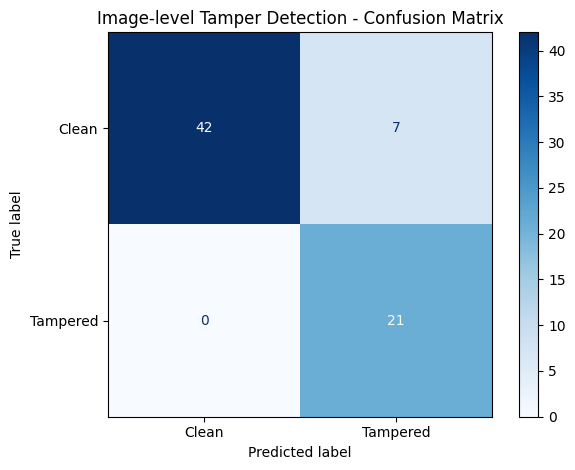

Image-level AUC: 0.9252
✅ Saved image-level artifacts: /content/drive/MyDrive/AI TraceFinder/ForensicsScannerData/artifacts_tamper_image_v1


In [29]:
# Image-level tamper classifier: average 18-D patch features per image; calibrated RBF-SVM with group split.

import os, csv, json, pickle, numpy as np, cv2, pywt, math, re
from skimage.feature import local_binary_pattern as sk_lbp
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


MANIFEST_CSV = f"{ROOT}/manifests/tamper_manifest_grouped_ext.csv"
ART_IMG = f"{ROOT}/artifacts_tamper_image_v1"
os.makedirs(ART_IMG, exist_ok=True)

IMG_SIZE=(256,256); PATCH=128; STRIDE=64; MAX_PATCHES=16  # extract more patches but aggregate by mean

def load_to_residual(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(f"Cannot read {path}")
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    cA,(cH,cV,cD)=pywt.dwt2(img,"haar"); cH.fill(0); cV.fill(0); cD.fill(0)
    den=pywt.idwt2((cA,(cH,cV,cD)),"haar")
    return (img - den).astype(np.float32)

def extract_patches(res, patch=PATCH, stride=STRIDE, limit=MAX_PATCHES, seed=42):
    H,W=res.shape
    ys=list(range(0,H-patch+1,stride)); xs=list(range(0,W-patch+1,stride))
    coords=[(y,x) for y in ys for x in xs]
    rng=np.random.RandomState(seed); rng.shuffle(coords)
    coords=coords[:min(limit, len(coords))]
    return [res[y:y+patch, x:x+patch] for y,x in coords]

def lbp_hist_safe(img, P=8, R=1.0):
    rng=float(np.ptp(img))
    g=np.zeros_like(img, dtype=np.float32) if rng<1e-12 else (img - float(np.min(img))) / (rng + 1e-8)
    g8=(g*255.0).astype(np.uint8)
    codes=sk_lbp(g8,P=P,R=R,method="uniform")
    n_bins=P+2
    hist,_=np.histogram(codes,bins=np.arange(n_bins+1),density=True)
    return hist.astype(np.float32)

def fft_radial_energy(img, K=6):
    f=np.fft.fftshift(np.fft.fft2(img)); mag=np.abs(f)
    h,w=mag.shape; cy,cx=h//2,w//2
    yy,xx=np.ogrid[:h,:w]; r=np.sqrt((yy-cy)**2+(xx-cx)**2)
    bins=np.linspace(0,r.max()+1e-6,K+1)
    feats=[]
    for i in range(K):
        m=(r>=bins[i])&(r<bins[i+1]); feats.append(float(mag[m].mean() if m.any() else 0.0))
    return np.asarray(feats, dtype=np.float32)

def contrast_stat(img):
    return np.asarray([float(np.std(img)) , float(np.mean(np.abs(img - np.mean(img))))], dtype=np.float32)

def patch_feat(p):
    return np.concatenate([lbp_hist_safe(p,8,1.0), fft_radial_energy(p,6), contrast_stat(p)], axis=0)  # 18-D

with open(MANIFEST_CSV,"r") as fh:
    rr=list(csv.DictReader(fh))
paths  = np.array([r["path"] for r in rr], dtype=object)
labels = np.array([int(r["label"]) for r in rr], dtype=np.int64)
groups = np.array([r["page_id"] for r in rr], dtype=object)
domain = np.array([r["domain"] for r in rr], dtype=object)
ttype  = np.array([r["tamper_type"] for r in rr], dtype=object)

# Build image-level features by averaging 16–20 patches (robust mean)
X_img, y_img, d_img, g_img, t_img, p_img = [], [], [], [], [], []
for i, pth in enumerate(paths):
    res = load_to_residual(pth)
    patches = extract_patches(res, limit=MAX_PATCHES, seed=1234 + i)
    feats = np.stack([patch_feat(p) for p in patches], 0) if patches else np.zeros((1,18), np.float32)
    X_img.append(np.mean(feats, axis=0))
    y_img.append(labels[i])
    d_img.append(domain[i])
    g_img.append(groups[i])
    t_img.append(ttype[i])
    p_img.append(pth)

X_img = np.asarray(X_img, np.float32)
y_img = np.asarray(y_img, np.int64)
d_img = np.asarray(d_img, dtype=object)
g_img = np.asarray(g_img, dtype=object)
t_img = np.asarray(t_img, dtype=object)
p_img = np.asarray(p_img, dtype=object)

# Group split at image level
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
tr_i, va_i = next(sgkf.split(X_img, y_img, g_img))

scaler = StandardScaler().fit(X_img[tr_i])
Xt = scaler.transform(X_img[tr_i])
Xv = scaler.transform(X_img[va_i])

base = SVC(kernel="rbf", C=0.8, gamma="scale", probability=False, class_weight="balanced", random_state=42)
clf  = CalibratedClassifierCV(base, method="sigmoid", cv=10).fit(Xt, y_img[tr_i])

# Metrics (image-level)
ytr_pred = clf.predict(Xt); yva_pred = clf.predict(Xv)
print("Train accuracy (image):", f"{accuracy_score(y_img[tr_i], ytr_pred):.4f}")
print("Test accuracy (image):",  f"{accuracy_score(y_img[va_i], yva_pred):.4f}")
print("Classification report (image):\n", classification_report(y_img[va_i], yva_pred, target_names=["Clean","Tampered"], zero_division=0))
cm = confusion_matrix(y_img[va_i], yva_pred, labels=[0,1])

plt.figure(figsize=(0.3, 0.3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Clean", "Tampered"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Image-level Tamper Detection - Confusion Matrix")
plt.tight_layout()
plt.show()

probs_va = clf.predict_proba(Xv)[:,1]
print("Image-level AUC:", f"{roc_auc_score(y_img[va_i], probs_va):.4f}")

def best_thr(y, p):
    fpr,tpr,thr = roc_curve(y, p)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])

thr_global = best_thr(y_img[va_i], probs_va)
thr_by_domain = {}
for dom in ["orig_pdf_tif","tamper_dir","mobile_scan"]:
    m = (d_img[va_i]==dom)
    if m.any() and len(np.unique(y_img[va_i][m]))==2:
        thr_by_domain[dom] = best_thr(y_img[va_i][m], probs_va[m])

# Domain offsets (retain)
if "mobile_scan" in thr_by_domain:
    thr_by_domain["mobile_scan"] = float(min(1.0, thr_by_domain["mobile_scan"] + 0.05))
if "tamper_dir" in thr_by_domain:
    thr_by_domain["tamper_dir"] = float(min(1.0, thr_by_domain["tamper_dir"] + 0.03))

with open(f"{ART_IMG}/image_scaler.pkl","wb") as f: pickle.dump(scaler,f)
with open(f"{ART_IMG}/image_svm_sig.pkl","wb") as f: pickle.dump(clf,f)
with open(f"{ART_IMG}/image_thresholds.json","w") as f: json.dump({"global": thr_global, "by_domain": thr_by_domain}, f)
print("✅ Saved image-level artifacts:", ART_IMG)


In [30]:
import shutil

ROOT = "/content/drive/MyDrive/AI TraceFinder/ForensicsScannerData"

shutil.make_archive(
    "/content/objective2_artifacts",
    "zip",
    f"{ROOT}/artifacts_tamper_patch"
)

shutil.make_archive(
    "/content/objective2_artifacts_pair",
    "zip",
    f"{ROOT}/artifacts_tamper_pair"
)

print("Download these zips:")
print("- /content/objective2_artifacts.zip")
print("- /content/objective2_artifacts_pair.zip")


Download these zips:
- /content/objective2_artifacts.zip
- /content/objective2_artifacts_pair.zip


In [31]:
from google.colab import files

files.download("/content/objective2_artifacts.zip")
files.download("/content/objective2_artifacts_pair.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>